## Grism Utils

In [30]:
import astropy.io.fits as fits
import numpy as np
import matplotlib.pyplot as plt
import glob

from astropy.time import Time
from astropy.coordinates import EarthLocation, SkyCoord
import astropy.units as u
from astropy.io.fits import getdata
from astroquery.simbad import Simbad

import pandas as pd
import os
import sys
import re
from scipy.ndimage import gaussian_filter1d

In [31]:
import importlib
import grism_utils_v2
importlib.reload(grism_utils_v2)
from grism_utils_v2 import spectrum

# Specify basepath and target

Change the basepath to the RLMT folder and specify your target of choice to derive a wavelength calibration

In [ ]:
# Specify filter (hrg or lrg)

filter = 'hrg'

In [22]:
# Please paste in your own directories here for saving output files
out_folder = os.path.expanduser('~/Desktop/Code/')
drive_path = os.path.expanduser('~/gdrive/Shared Drives/MACRO-Be/resources/Data') #Comment this out if you do not have drive mounted

#Specify a basepath
# basepath = os.path.expanduser('~/Desktop/Code/reduced_data/')
basepath = os.path.expanduser('~/gdrive/Shared drives/MACRO-Be/resources/Data/raw_data/')

# /Users/research/Desktop/RLMT/2026-01-21

## Priority Targets
# target = 'V442_And'
# target = '69_Ori'
target = 'Alpha_Lyr'

# ----- FLEXIBLE HANDLING -----
if isinstance(target, str):
    targets = [target]
else:
    targets = list(target)

# Build regex to match any target alias safely
target_pattern = re.compile(
    r"(?<![A-Za-z0-9])(" + "|".join(re.escape(t) for t in targets) + r")(?![A-Za-z0-9])",
    re.IGNORECASE
)

# Create image and calibration file lists

img_files = []

if filter =='hrg':
    patterns = [
        f"{basepath}/2025*/*hrg*.fz",
        f"{basepath}/2026*/*hrg*.fz"  # broad pattern
    ]
elif filter == 'lrg':
    patterns = [
        f"{basepath}/2025*/*lrg*.fz",
        f"{basepath}/2026*/*lrg*.fz"  # broad pattern
    ]

for pattern in patterns:
    for m in glob.glob(pattern):
        base = os.path.basename(m)
        if re.search(target_pattern, base):
            img_files.append(m)

img_files = sorted(img_files)
n_img_files = len(img_files)

print('')
print(f'Found {n_img_files} science images')
print('')


Found 202 science images



In [23]:
# Filter by centering
centered_list = []

for i in range(len(img_files)):
    hdu = fits.open(img_files[i])
    hdul = hdu[1].header
    centered = hdul["CENTERED"]
    if centered == False:
        try:
            winstabl = hdul["WINSTABL"]
            centered_list.append(winstabl)
        except: 
            centered_list.append(centered)
    else:
        centered_list.append(centered)

i = 0
while i < len(centered_list):
  if centered_list[i] == False:
    # print(f'Not centered, deleting image: {img_files[i]}')
    del img_files[i]
    del centered_list[i]
    continue
  else:
    i += 1

# for i in range(len(img_files)):
#   print(img_files[i], f'Centering = {centered_list[i]}')

#Print the result
print(f"{len(img_files)} of {n_img_files} images are centered")

for i in range(len(img_files)):
   print(f'{i}: {img_files[i]}')

174 of 202 images are centered
0: /Users/joshuamarine/gdrive/Shared drives/MACRO-Be/resources/Data/raw_data/2026-04-16/jos_Alpha_Lyr_hrg_2s_2026-04-16T11-25-54_calibrated.fts.fz
1: /Users/joshuamarine/gdrive/Shared drives/MACRO-Be/resources/Data/raw_data/2026-04-16/jos_Alpha_Lyr_hrg_2s_2026-04-16T11-26-03_calibrated.fts.fz
2: /Users/joshuamarine/gdrive/Shared drives/MACRO-Be/resources/Data/raw_data/2026-04-16/jos_Alpha_Lyr_hrg_2s_2026-04-16T11-30-56_calibrated.fts.fz
3: /Users/joshuamarine/gdrive/Shared drives/MACRO-Be/resources/Data/raw_data/2026-04-16/jos_Alpha_Lyr_hrg_2s_2026-04-16T11-31-05_calibrated.fts.fz
4: /Users/joshuamarine/gdrive/Shared drives/MACRO-Be/resources/Data/raw_data/2026-04-16/jos_Alpha_Lyr_hrg_4s_2026-04-16T11-25-32_calibrated.fts.fz
5: /Users/joshuamarine/gdrive/Shared drives/MACRO-Be/resources/Data/raw_data/2026-04-16/jos_Alpha_Lyr_hrg_4s_2026-04-16T11-25-43_calibrated.fts.fz
6: /Users/joshuamarine/gdrive/Shared drives/MACRO-Be/resources/Data/raw_data/2026-04-16

# Doppler Shift Wavelength Correction

You do not have to change anything in this section, just run all of the blocks

In [24]:
# Query Simbad for the recessional velocity of the target

# Reset to default fields
Simbad.reset_votable_fields()

# List available votable fields
print("Available votable fields:")
print(Simbad.list_votable_fields())

Simbad.add_votable_fields('rvz_radvel')

star_name = target
result_table = Simbad.query_object(star_name)

if result_table is None:
    print(f"No results found for {star_name}.")
else:
    print("Returned columns:", result_table.colnames)
    
    if 'rvz_radvel' in result_table.colnames:
        rv = result_table['rvz_radvel'][0]
        if rv is None:
            print('')
            print(f"No radial (recessional) velocity available for {star_name}.")
            print('')
        else:
            print('')
            print(f"The radial (recessional) velocity of {star_name} is {rv} km/s.")
            print('')
    else:
        print("Radial velocity column not found in the result. Available columns are:")
        print(result_table.colnames)

Available votable fields:
    name    ...     type   
----------- ... -----------
mesDiameter ...       table
      mesPM ...       table
     mesISO ...       table
     mesSpT ...       table
  allfluxes ...       table
      ident ...       table
       flux ...       table
   mesOtype ...       table
     mesPLX ...       table
   otypedef ...       table
        ... ...         ...
          K ... filter name
          u ... filter name
          g ... filter name
          r ... filter name
          i ... filter name
          z ... filter name
          G ... filter name
      F150W ... filter name
      F200W ... filter name
      F444W ... filter name
Length = 116 rows
Returned columns: ['main_id', 'ra', 'dec', 'coo_err_maj', 'coo_err_min', 'coo_err_angle', 'coo_wavelength', 'coo_bibcode', 'rvz_radvel', 'matched_id']

The radial (recessional) velocity of Alpha_Lyr is -13.5 km/s.



In [25]:
# Calculate earth radial velocity correction with astropy for rigel based on DATE-OBS in header

i = 50

# Get the DATE-OBS from the header
# with fits.open(max_exptime_images[img_index]) as hdul:
with fits.open(img_files[i]) as hdul:
    header = hdul[1].header
# header = fits.getheader(max_exptime_images[img_index])
date_obs = header['DATE-OBS']
print(date_obs)

target_name = target.replace('_',' ')
print(f'Target: {target_name}')

# Should really pull the target from the header...
target_sc = SkyCoord.from_name(target_name)
print(target_sc)

# Get the observatory location
obs_loc = EarthLocation.of_site('Winer')
print(obs_loc)

# Convert date_obs to astropy time
t = Time(date_obs, format='isot', scale='utc', location=obs_loc)
print(t)

radial_vel_correction = target_sc.radial_velocity_correction(obstime=t).to('km/s')
print("Earth motion velocity: ", radial_vel_correction)

2026-06-07T07:29:26.75
Target: Alpha Lyr
<SkyCoord (ICRS): (ra, dec) in deg
    (279.23473479, 38.78368896)>
(-1912384.9030059641, -5087336.881556098, 3329722.618648529) m
2026-06-07T07:29:26.750
Earth motion velocity:  6.974735729691865 km / s


In [26]:
# Caclulate a wavelength correction factor based on target recessional velocity and Earth motion

rv_tot = (rv*u.km/u.s + radial_vel_correction)
print(f'Total radial velocity motion: {rv_tot}')

c = 299792.458 * u.km/u.s  # Speed of light in km/s
z = (rv*u.km/u.s + radial_vel_correction)/c
wavelength_correction = 1 + z
print("Wavelength Correction Factor:", wavelength_correction)
if wavelength_correction < 1:
    print('Light is blue shifted')
if wavelength_correction > 1:
    print('Light is red shifted')

Total radial velocity motion: -6.525264270308135 km / s
Wavelength Correction Factor: 0.9999782340612775
Light is blue shifted


# Image Processing --> Normalized Spectrum

You do not have to change anything in this section, just run all of the blocks

Processing image: /Users/joshuamarine/gdrive/Shared drives/MACRO-Be/resources/Data/raw_data/2026-06-07/jos_Alpha_Lyr_hrg_3s_2026-06-07T07-12-11_calibrated.fts.fz


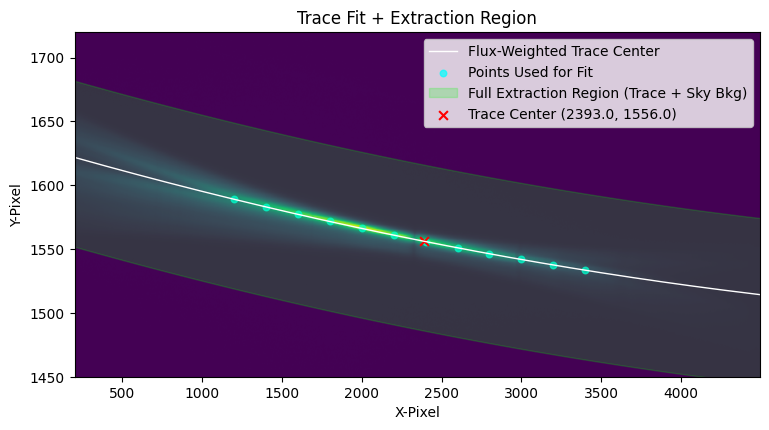

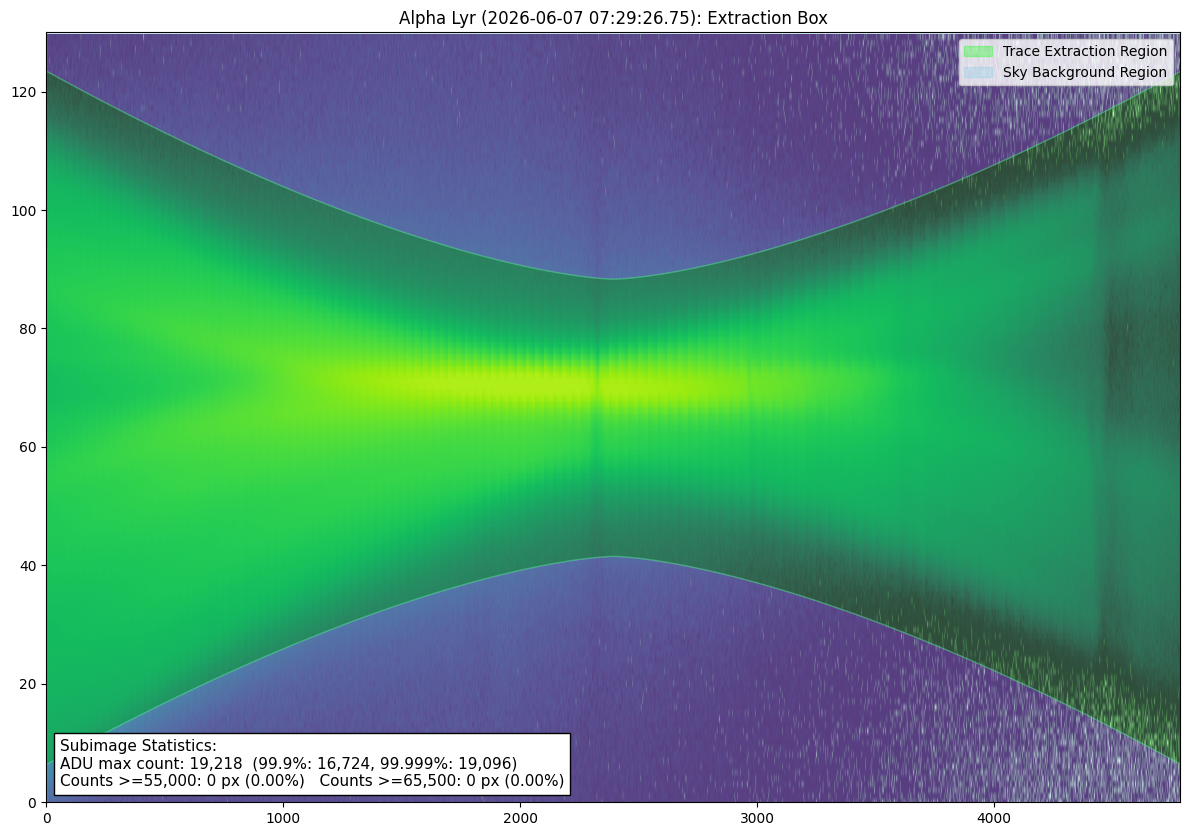

/Users/joshuamarine/Desktop/Code/Be-Stars/grism_utils_v2.py:1350: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


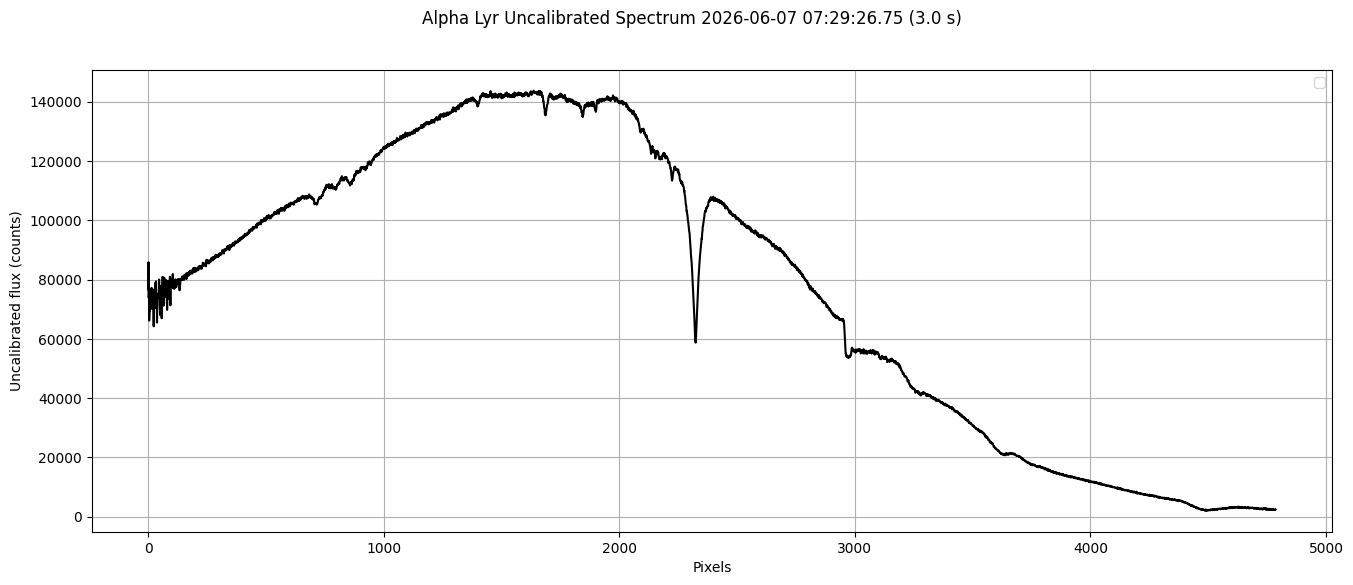

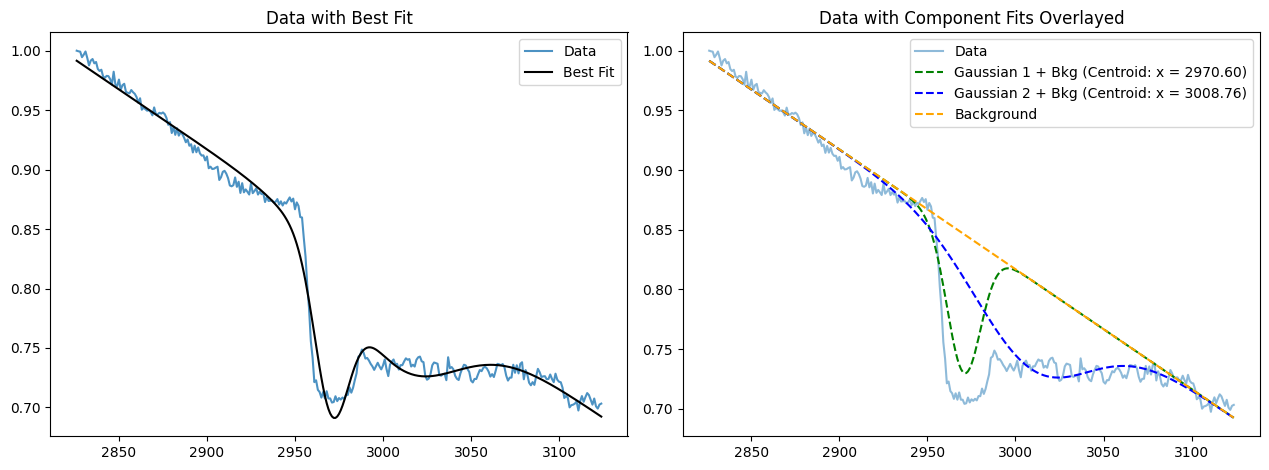

In [27]:
grism_image = img_files[i]
print(f'Processing image: {grism_image}')

S = spectrum(grism_image, calib_spectrum=None, filter=filter)

# print(f'Moon Angle & Phase: {S.moonangle:.2f} degrees, {(S.moonphase * 100):.2f} %')
S.remove_hot_pixels()
try:
    trace_center, cutouts, subim = S.fit_trace(plot = True, show_points = True, curved = True, method = 'gauss') # can try method = 'gauss' if fitting poorly
except Exception as e:
    trace_center, cutouts, subim = S.fit_trace(plot = True, show_points = True, curved = True, method = 'max') # can try method = 'gauss' if fitting poorly
# trace_center, cutouts, subim = S.fit_trace(plot = True, show_points = True, curved = True, method = 'gauss')
spec = S.extract_spectrum(show_box = True, plot = True, curved_box = True, sat_level = 55000)
# telluric_pixel = S.fit_telluric(x_guess = None, plot = True, debugging = True)
telluric_pixel = S.fit_telluric_old(x_guess = None, plot = True, debugging = False, manual_override = False)
# print(telluric_pixel)

pixels, fluxes = S.pixel_mask, S.amp_uncal_mask

# Derive Wavelength Solution + Gain Curve

In [32]:
def load_stelib_spectrum(star_name, folder_path):
    """
    Load STELIB spectrum from a CSV file given a star name and folder path.

    Parameters:
    - star_name: str, like 'HD135722'
    - folder_path: str, full path to the folder in Google Drive containing the CSVs

    Returns:
    - df: Pandas DataFrame with columns 'wavelength' and 'flux'
    """
    # Build expected filename
    # Remove underscores in star names
    star_name = star_name.replace('_', '')
    for file in os.listdir(folder_path):
        if star_name in file and file.endswith('.csv'):
            file_path = os.path.join(folder_path, file)
            df = pd.read_csv(file_path)
            return df
    raise FileNotFoundError(f"No file found for star: {star_name}")

def match_and_interpolate(waves_data, flux_data, waves_ref_orig, flux_ref_orig, num_points=1000):
    """
    Safely interpolate both observed and reference spectra to a common grid.
    """
    # Copy reference arrays to avoid in-place modification
    waves_ref = np.copy(waves_ref_orig)
    flux_ref = np.copy(flux_ref_orig)

    # Ensure all arrays are 1D numpy arrays
    waves_data = np.array(waves_data).flatten()
    flux_data = np.array(flux_data).flatten()
    waves_ref = np.array(waves_ref).flatten()
    flux_ref = np.array(flux_ref).flatten()

    # Check that arrays match in size before interpolating
    if len(waves_data) != len(flux_data):
        raise ValueError(f"waves_data and flux_data lengths do not match: {len(waves_data)} vs {len(flux_data)}")
    if len(waves_ref) != len(flux_ref):
        raise ValueError(f"waves_ref and flux_ref lengths do not match: {len(waves_ref)} vs {len(flux_ref)}")

    # Determine overlapping wavelength range
    min_wave = max(np.min(waves_data), np.min(waves_ref))
    max_wave = min(np.max(waves_data), np.max(waves_ref))

    if min_wave >= max_wave:
        raise ValueError("No overlapping wavelength region between data and reference.")

    # Define common wavelength grid
    wave_grid = np.linspace(min_wave, max_wave, num_points)

    # Interpolate both spectra onto the same grid
    flux_data_interp = np.interp(wave_grid, waves_data, flux_data)
    flux_ref_interp = np.interp(wave_grid, waves_ref, flux_ref)

    return wave_grid, flux_data_interp, flux_ref_interp

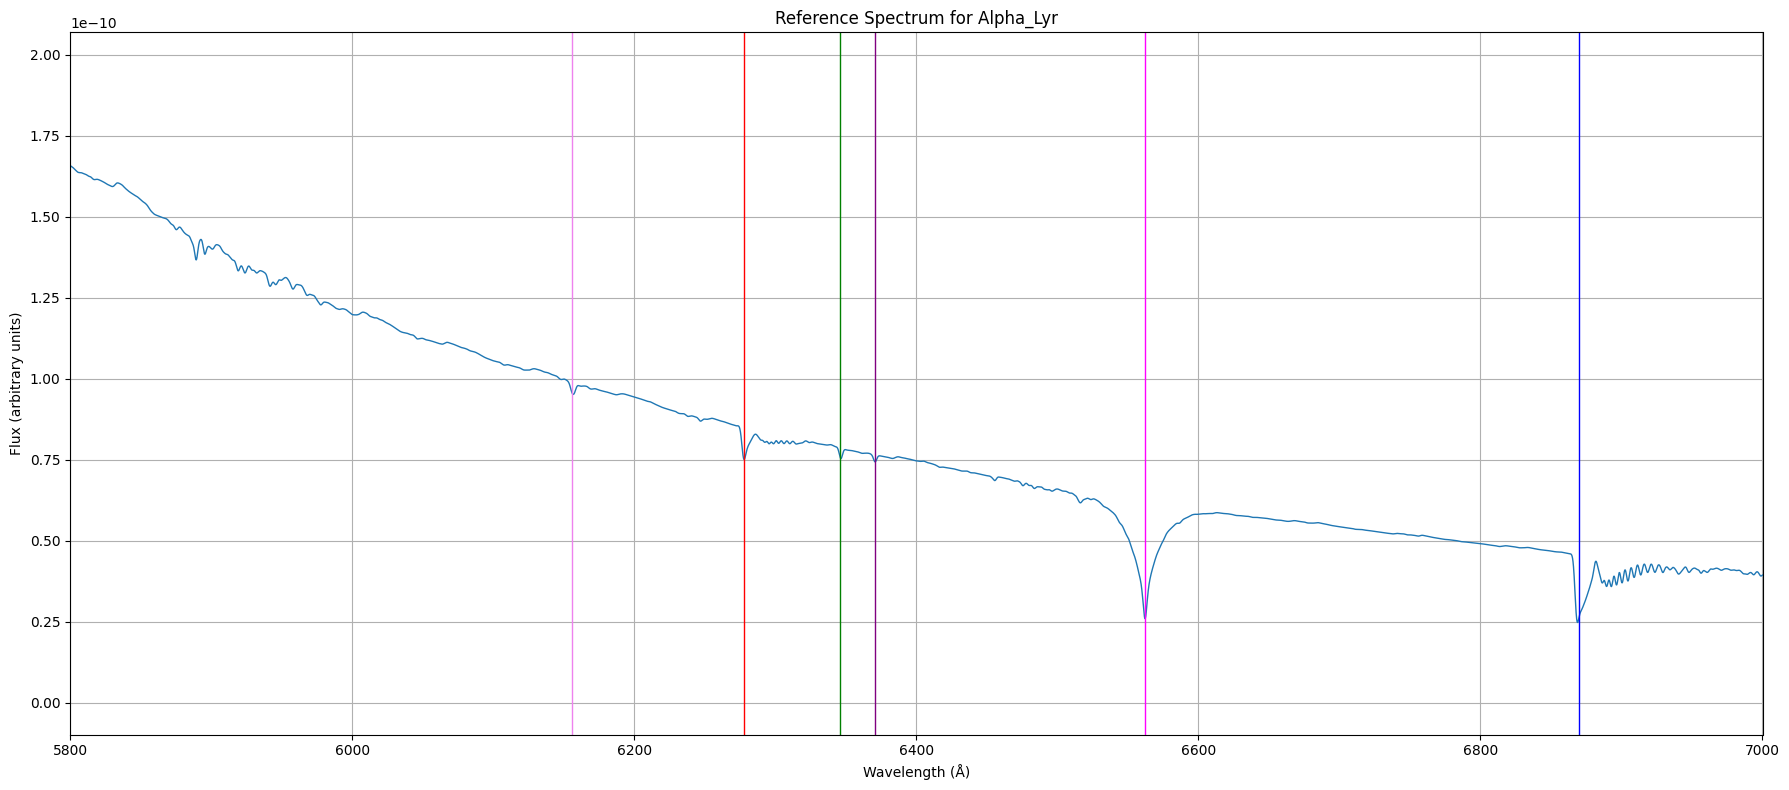

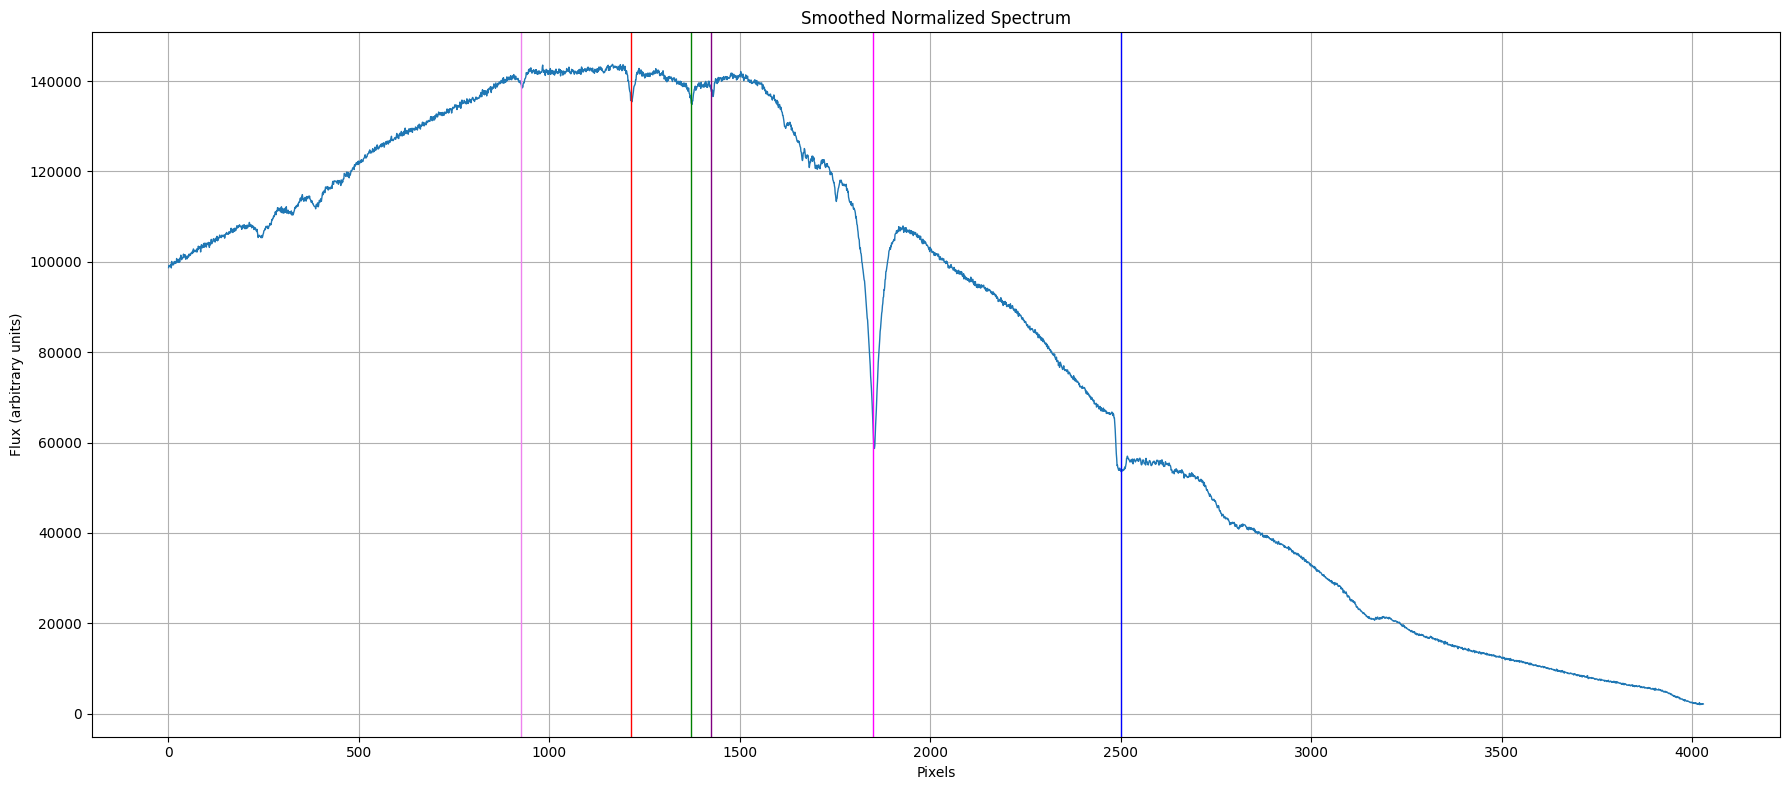

In [33]:
# Match features in RLMT spectrum to reference spectrum

cal_star = 'Alpha_Lyr'

img_path = 'ESO/Alpha_Lyr_ESO.fits'
# img_path1 = 'CALSPEC/alpha_lyr_stis_012.fits'

im, hdr = getdata(img_path, 1, header=True)

cal_waves = im[0][0]
cal_fluxes = im[0][1]*10e-16 # Convert to erg/s/cm^2/Å

R = 6000

sigma_pix = (6562.8/R) / np.median(np.diff(cal_waves))
flux_ref_conv = gaussian_filter1d(cal_fluxes, sigma_pix)

# plt.figure(figsize=(10, 4))
# plt.plot(spectrum_df['Wavelength'], spectrum_df['Flux'], lw=1)
# plt.xlabel('Wavelength (Å)')
# plt.ylabel('Flux (arbitrary units)')
# plt.title(f'STELIB Spectrum for {cal_star}')
# plt.grid(True)
# plt.tight_layout()
# plt.show()

colors = ['violet', 'red', 'green', 'purple', 'magenta', 'blue', 'brown', 'black', 'orange', 'grey']
# wavelength_guesses = [4102, 4340, 4470, 4861, 4920, 5875, 6563, 6870]
wavelength_guesses = [6156, 6278, 6346, 6371, 6562, 6870]

plt.figure(figsize=(18, 8))
plt.plot(cal_waves, flux_ref_conv, lw=1)
plt.xlabel('Wavelength (Å)')
plt.ylabel('Flux (arbitrary units)')
plt.title(f'Reference Spectrum for {cal_star}')

for i in range(len(wavelength_guesses)):
    plt.axvline(wavelength_guesses[i], color = colors[i], lw = 1)

plt.xlim(5800,7000)
# plt.xlim(4000,8000)
# plt.ylim(0.15e-10,0.6e-10)
plt.grid(True)
plt.tight_layout()
plt.show()

# pixel_guesses = [302, 413, 480, 658, 686, 1412, 2034, 2247]
pixel_guesses = [926, 1213, 1371, 1424, 1849, 2501]

plt.figure(figsize=(18, 8))
# plt.plot(pixels, spec_flux, lw=1)
plt.plot(pixels, fluxes, lw=1)
plt.xlabel('Pixels')
plt.ylabel('Flux (arbitrary units)')
plt.title(f'Smoothed Normalized Spectrum')

for i in range(len(pixel_guesses)):
    plt.axvline(pixel_guesses[i], color = colors[i], lw = 1)

plt.grid(True)
plt.tight_layout()
plt.show()

In [34]:
hdr

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =              5218836 / length of dimension 1                          
NAXIS2  =                    1 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                    6 / number of table fields                         
TTYPE1  = 'WAVE    '                                                            
TFORM1  = '186387D '                                                            
TTYPE2  = 'FLUX_REDUCED'                                                        
TFORM2  = '186387E '                                                            
TTYPE3  = 'ERR_REDUCED'     

In [ ]:
def wavelength_dependent_gaussian_convolution(wave, flux, R):
    """
    Convolve a spectrum to constant resolving power R
    using a wavelength-dependent Gaussian kernel.

    Parameters
    ----------
    wave : ndarray
        Wavelength array (Å), monotonic
    flux : ndarray
        Flux array
    R : float
        Target resolving power

    Returns
    -------
    flux_conv : ndarray
        Resolution-matched spectrum
    """

    wave = np.asarray(wave)
    flux = np.asarray(flux)

    # Local dispersion (Å / pix)
    dw = np.gradient(wave)

    flux_conv = np.zeros_like(flux)

    for i in range(len(wave)):
        fwhm_lambda = wave[i] / R
        sigma_lambda = fwhm_lambda / 2.355
        sigma_pix = sigma_lambda / dw[i]

        # Limit kernel size for stability
        sigma_pix = np.clip(sigma_pix, 0.5, 50)

        # Apply local Gaussian
        kernel_radius = int(4 * sigma_pix)
        lo = max(0, i - kernel_radius)
        hi = min(len(flux), i + kernel_radius + 1)

        x = np.arange(lo, hi)
        g = np.exp(-0.5 * ((x - i) / sigma_pix) ** 2)
        g /= g.sum()

        flux_conv[i] = np.sum(flux[lo:hi] * g)

    return flux_conv

def wavelength_dependent_gaussian_convolution_dlambda(wave, flux, delta_lambda):
    """
    Convolve a spectrum to constant FWHM in wavelength (delta_lambda)
    using a Gaussian kernel.

    Parameters
    ----------
    wave : ndarray
        Wavelength array (Å), monotonic.
    flux : ndarray
        Flux array.
    delta_lambda : float
        Target Gaussian FWHM in wavelength units (Å).

    Returns
    -------
    flux_conv : ndarray
        Convolved spectrum.
    """

    wave = np.asarray(wave, dtype=float)
    flux = np.asarray(flux, dtype=float)

    if wave.ndim != 1 or flux.ndim != 1:
        raise ValueError("wave and flux must be 1D arrays.")
    if len(wave) != len(flux):
        raise ValueError("wave and flux must have the same length.")
    if delta_lambda <= 0:
        raise ValueError("delta_lambda must be positive.")

    # Local dispersion (Å / pix)
    dw = np.gradient(wave)

    # Constant Gaussian width in wavelength
    sigma_lambda = delta_lambda / 2.355

    flux_conv = np.zeros_like(flux)

    for i in range(len(wave)):
        sigma_pix = sigma_lambda / dw[i]

        # Limit kernel size for stability
        sigma_pix = np.clip(sigma_pix, 0.5, 50)

        kernel_radius = int(4 * sigma_pix)
        lo = max(0, i - kernel_radius)
        hi = min(len(flux), i + kernel_radius + 1)

        x = np.arange(lo, hi)
        g = np.exp(-0.5 * ((x - i) / sigma_pix) ** 2)
        g /= g.sum()

        flux_conv[i] = np.sum(flux[lo:hi] * g)

    return flux_conv

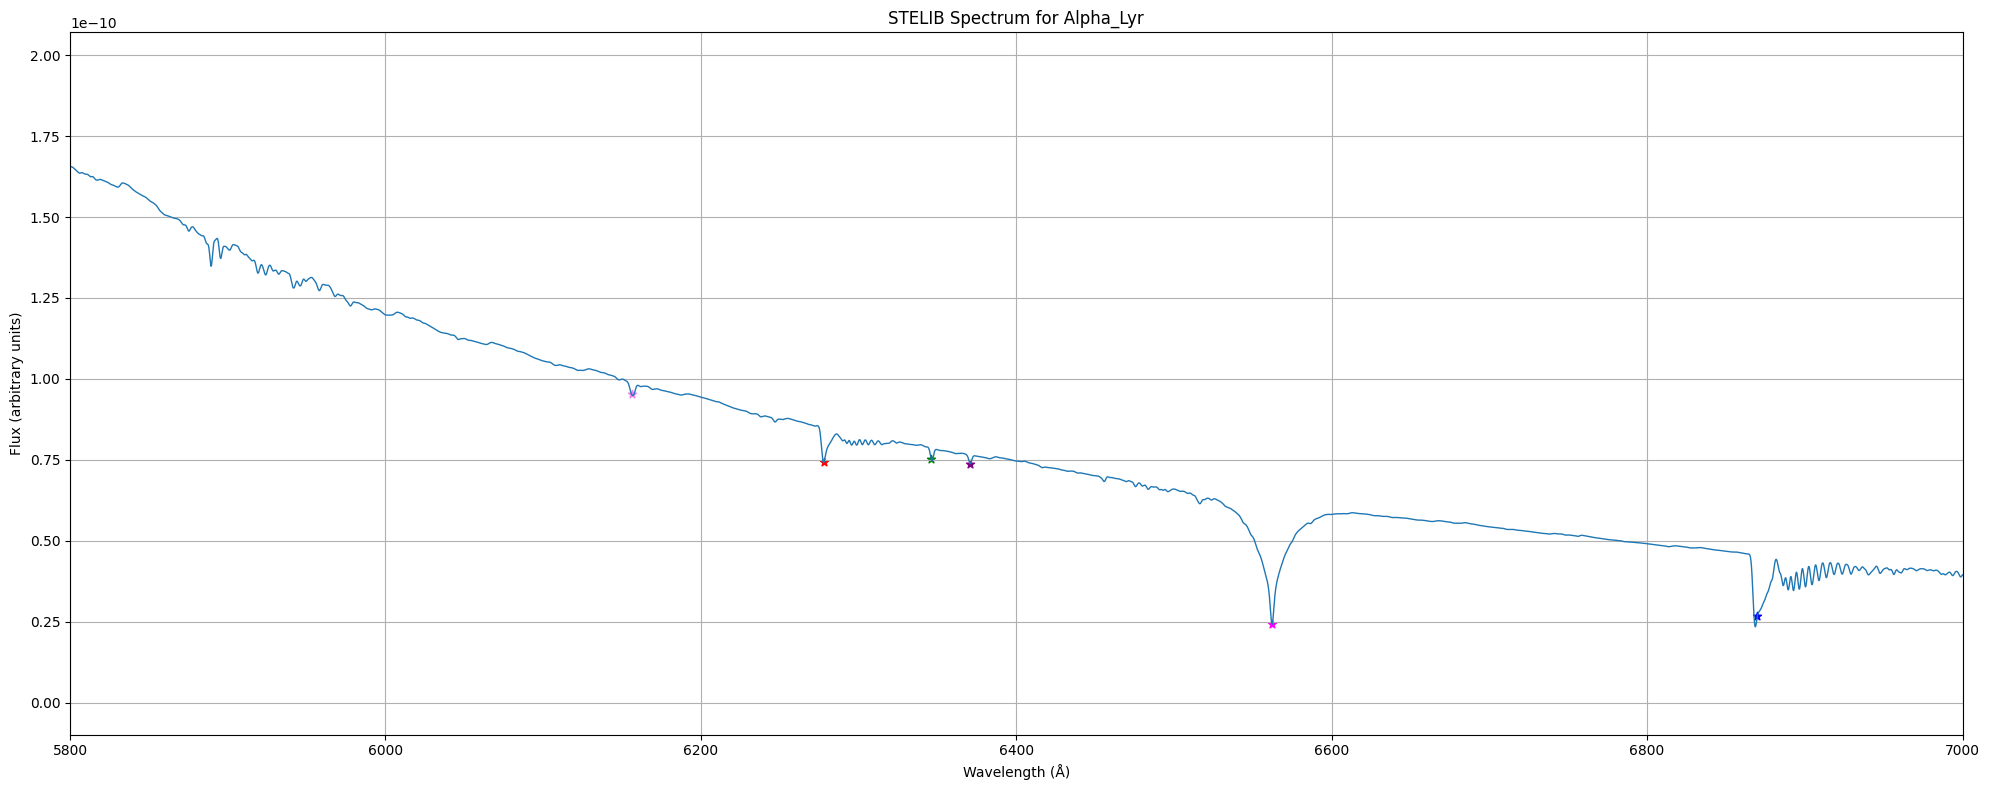

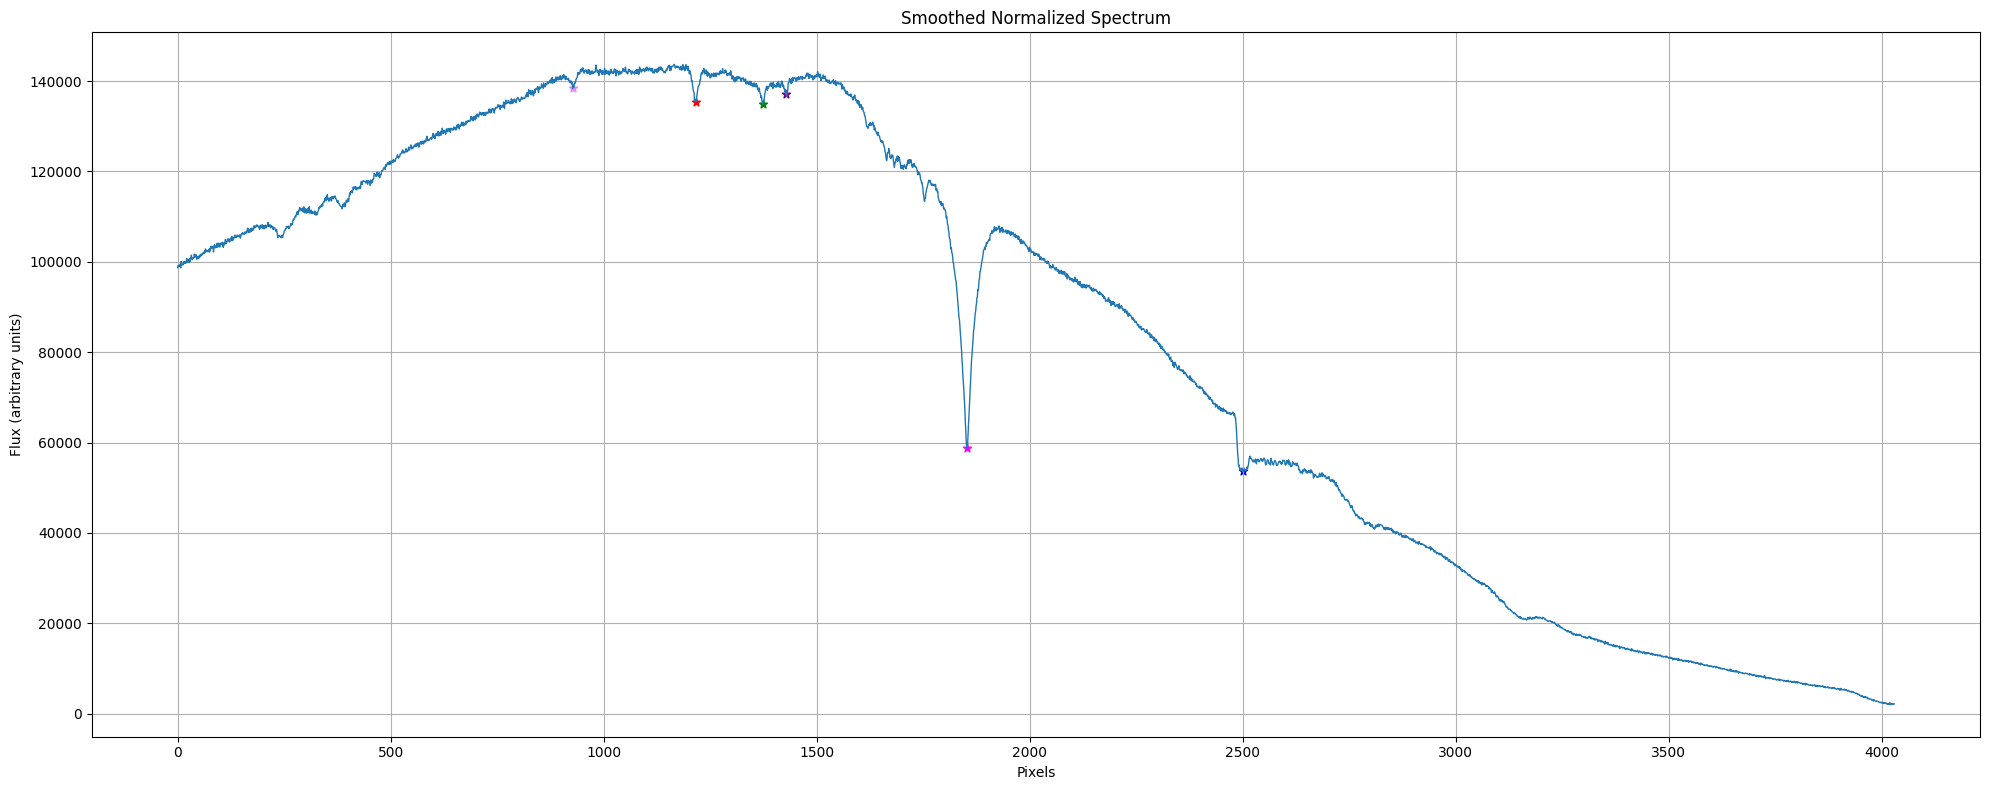

In [36]:
# Re-derive wavelength and pixel centroids

R = 3000

flux_ref_conv = wavelength_dependent_gaussian_convolution(
    cal_waves,
    cal_fluxes,
    R
)

wavelength_centroids = []

for wavelength_guess in wavelength_guesses:
    index = np.argmin(np.abs(cal_waves-wavelength_guess))
    mask = (cal_waves > cal_waves[index-5]) & (cal_waves < cal_waves[index + 5])
    min_flux = np.min(flux_ref_conv[mask])
    new_index = np.argmin(np.abs(flux_ref_conv - min_flux))
    new_wavelength = cal_waves[new_index]
    wavelength_centroids.append(new_wavelength)

pixel_centroids = []

for pixel_guess in pixel_guesses:
    index = np.argmin(np.abs(pixels-pixel_guess))
    mask = (pixels > pixels[index-5]) & (pixels < pixels[index + 5])
    min_flux = np.min(fluxes[mask])
    new_index = np.argmin(np.abs(fluxes - min_flux))
    new_pixel = pixels[new_index]
    pixel_centroids.append(new_pixel)

plt.figure(figsize=(20, 8))
plt.plot(cal_waves, flux_ref_conv, lw=1)
plt.xlabel('Wavelength (Å)')
plt.ylabel('Flux (arbitrary units)')
plt.title(f'STELIB Spectrum for {cal_star}')

for i in range(len(wavelength_centroids)):
    index = np.argmin(np.abs(cal_waves-wavelength_centroids[i]))
    plt.scatter(cal_waves[index], flux_ref_conv[index], color = colors[i], marker = '*')

plt.xlim(5800,7000)
# plt.xlim(4000,8000)
# plt.ylim(0.1e-10,0.6e-10)
# plt.ylim(0.0e-10, 1.75e-10)
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 8))
plt.plot(pixels, fluxes, lw=1)
plt.xlabel('Pixels')
plt.ylabel('Flux (arbitrary units)')
plt.title(f'Smoothed Normalized Spectrum')

for i in range(len(wavelength_centroids)):
    index = np.argmin(np.abs(pixels-pixel_centroids[i]))
    plt.scatter(pixels[index], fluxes[index], color = colors[i], marker = '*')

plt.grid(True)
plt.tight_layout()
plt.show()

In [37]:
wavelength_centroids

[np.float64(6156.070301717404),
 np.float64(6277.937262306383),
 np.float64(6346.069969412239),
 np.float64(6370.936821384914),
 np.float64(6562.064397319475),
 np.float64(6869.930476065517)]


=== Fit Report ===
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 11
    # data points      = 6
    # variables        = 4
    chi-square         = 1.33432766
    reduced chi-square = 0.66716383
    Akaike info crit   = -1.01999156
    Bayesian info crit = -1.85295368
    R-squared          = 0.99999583
[[Variables]]
    p_c0:  5795.13007 +/- 15.0572197 (0.26%) (init = 6358.503)
    p_c1:  0.36210089 +/- 0.02991824 (8.26%) (init = 0)
    p_c2:  3.0333e-05 +/- 1.8817e-05 (62.03%) (init = 1e-06)
    p_c3: -1.2956e-09 +/- 3.7225e-09 (287.33%) (init = 0)
[[Correlations]] (unreported correlations are < 0.100)
    C(p_c2, p_c3) = -0.9974
    C(p_c1, p_c2) = -0.9960
    C(p_c0, p_c1) = -0.9944
    C(p_c1, p_c3) = +0.9870
    C(p_c0, p_c2) = +0.9814
    C(p_c0, p_c3) = -0.9658

R^2 = 0.999995826


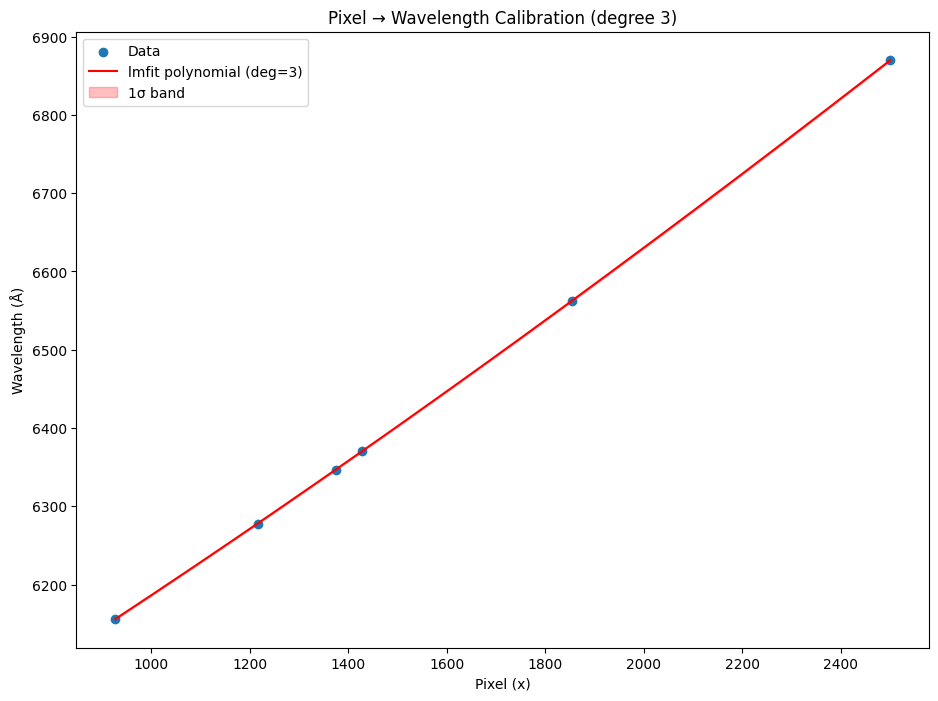

In [38]:
# Pixel --> Wavelength Solution Derivation

from lmfit.models import PolynomialModel
from lmfit import report_fit

degree = 3

xdata = np.asarray(pixel_centroids)
ydata = np.asarray(wavelength_centroids)

low = int(np.min(xdata))
high = int(np.max(xdata))
xplot = np.linspace(low, high, high - low + 1)

model = PolynomialModel(degree=degree, prefix='p_')

params = model.make_params()

# Sensible initial guesses
params['p_c0'].set(value=np.median(ydata))  # constant term

for k in range(1, degree + 1):
    params[f'p_c{k}'].set(value=0.0)

# Optional: weak regularization for higher orders
if degree >= 2:
    params['p_c2'].set(value=1e-6)

result = model.fit(ydata, params, x=xdata)

print("\n=== Fit Report ===")
report_fit(result)

yfit = result.eval(x=xplot)

resid = ydata - result.eval(x=xdata)
ss_res = np.sum(resid**2)
ss_tot = np.sum((ydata - np.mean(ydata))**2)
r2 = 1 - ss_res / ss_tot
print(f"\nR^2 = {r2:.9f}")

cov = result.covar
if cov is None:
    print("WARNING: covariance matrix unavailable — uncertainties cannot be computed.")
else:
    # Build Jacobian dynamically
    J = np.vstack([
        xplot**k for k in range(degree + 1)
    ])  # shape: (degree+1, N)

    var_y = np.einsum('ij,jk,ik->i', J.T, cov, J.T)
    sigma_y = np.sqrt(np.maximum(var_y, 0))

plt.figure(figsize=(11, 8))
plt.scatter(xdata, ydata, label='Data')
plt.plot(xplot, yfit, 'r', label=f'lmfit polynomial (deg={degree})')

if cov is not None:
    plt.fill_between(
        xplot,
        yfit - sigma_y,
        yfit + sigma_y,
        alpha=0.25,
        color='red',
        label='1σ band'
    )

plt.xlabel('Pixel (x)')
plt.ylabel('Wavelength (Å)')
plt.title(f'Pixel → Wavelength Calibration (degree {degree})')
plt.legend()
plt.show()

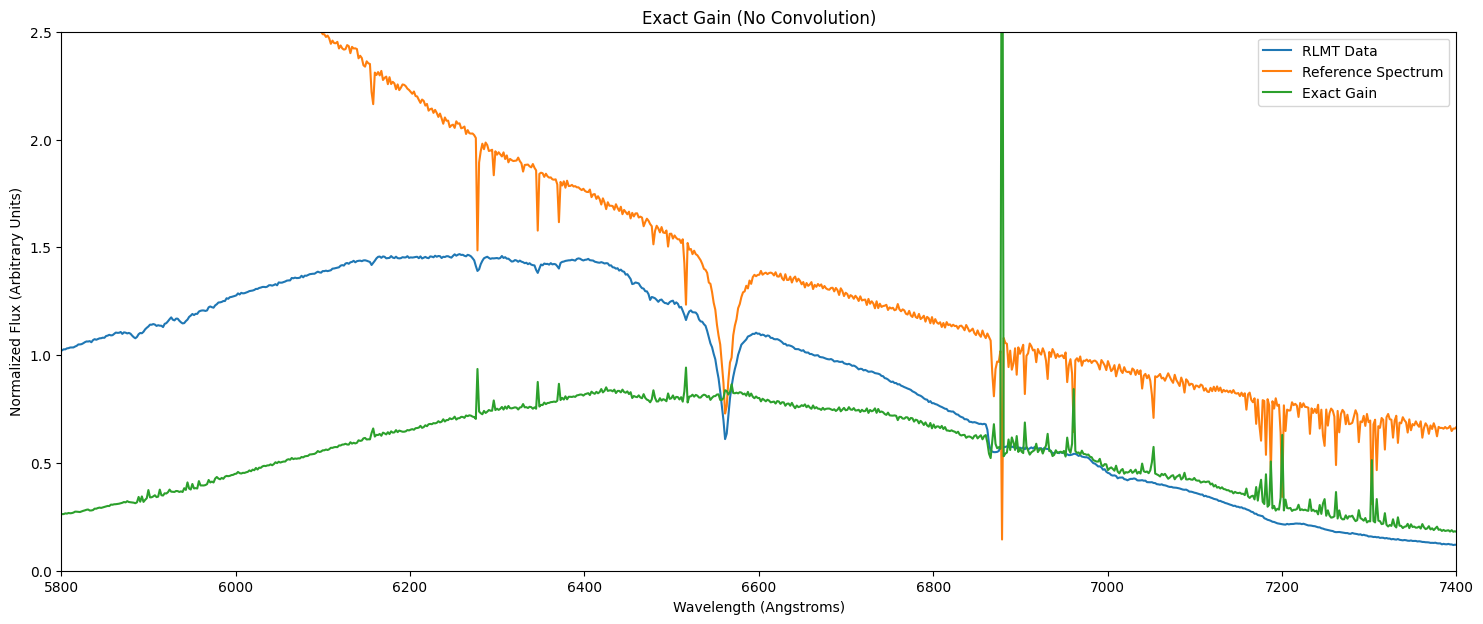

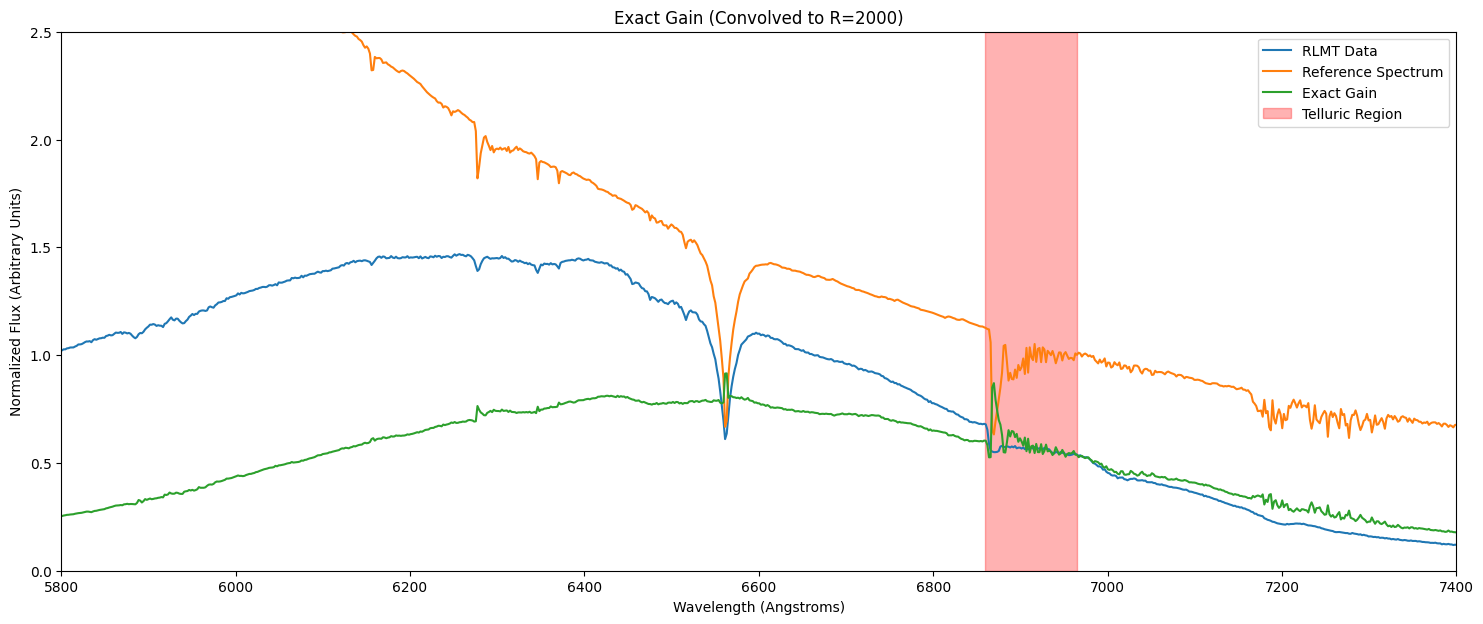

In [43]:
wavelengths = result.eval(x=pixels)
spec_flux_norm = fluxes/np.median(fluxes)
fluxes_norm = cal_fluxes/np.median(cal_fluxes)

wave_grid, flux_data_interp, flux_ref_interp = match_and_interpolate(wavelengths, spec_flux_norm, cal_waves, fluxes_norm)

plt.figure(figsize = (18,7))
plt.plot(wave_grid, flux_data_interp, label = 'RLMT Data')
plt.plot(wave_grid, flux_ref_interp, label = 'Reference Spectrum')
plt.plot(wave_grid, flux_data_interp/flux_ref_interp, label = 'Exact Gain')
plt.xlim(5800,7400)
plt.ylim(0,2.5)
plt.title('Exact Gain (No Convolution)')
plt.xlabel('Wavelength (Angstroms)')
plt.ylabel('Normalized Flux (Arbitrary Units)')
plt.legend()
plt.show()

R = 2000
dlambda = 6562.8/R

flux_ref_conv = wavelength_dependent_gaussian_convolution(
    cal_waves,
    cal_fluxes,
    R
)

# flux_ref_conv = wavelength_dependent_gaussian_convolution_dlambda(
#     cal_waves,
#     cal_fluxes,
#     dlambda
# )

# wave_grid, flux_data_interp, flux_ref_interp = match_and_interpolate(wavelengths, spec_flux_norm, cal_waves, flux_ref_conv/np.median(flux_ref_conv))
wave_grid, flux_data_interp, flux_ref_interp = match_and_interpolate(wavelengths, spec_flux_norm, cal_waves, flux_ref_conv/np.median(flux_ref_conv))

gain = flux_data_interp/flux_ref_interp

plt.figure(figsize = (18,7))
# plt.plot(cal_waves, flux_ref_conv/np.median(flux_ref_conv[900:4600]))
# plt.plot(wavelengths, spec_flux_norm)
plt.plot(wave_grid, flux_data_interp, label = 'RLMT Data')
plt.plot(wave_grid, flux_ref_interp, label = 'Reference Spectrum')
plt.plot(wave_grid, gain, label = 'Exact Gain')
# plt.axvline(6965)
plt.xlim(5800,7400)
plt.ylim(0,2.5)
plt.axvspan(6860, 6965, color='red', alpha=0.3, label='Telluric Region')
plt.title(f'Exact Gain (Convolved to R={R})')
plt.xlabel('Wavelength (Angstroms)')
plt.ylabel('Normalized Flux (Arbitrary Units)')
plt.legend()
plt.show()

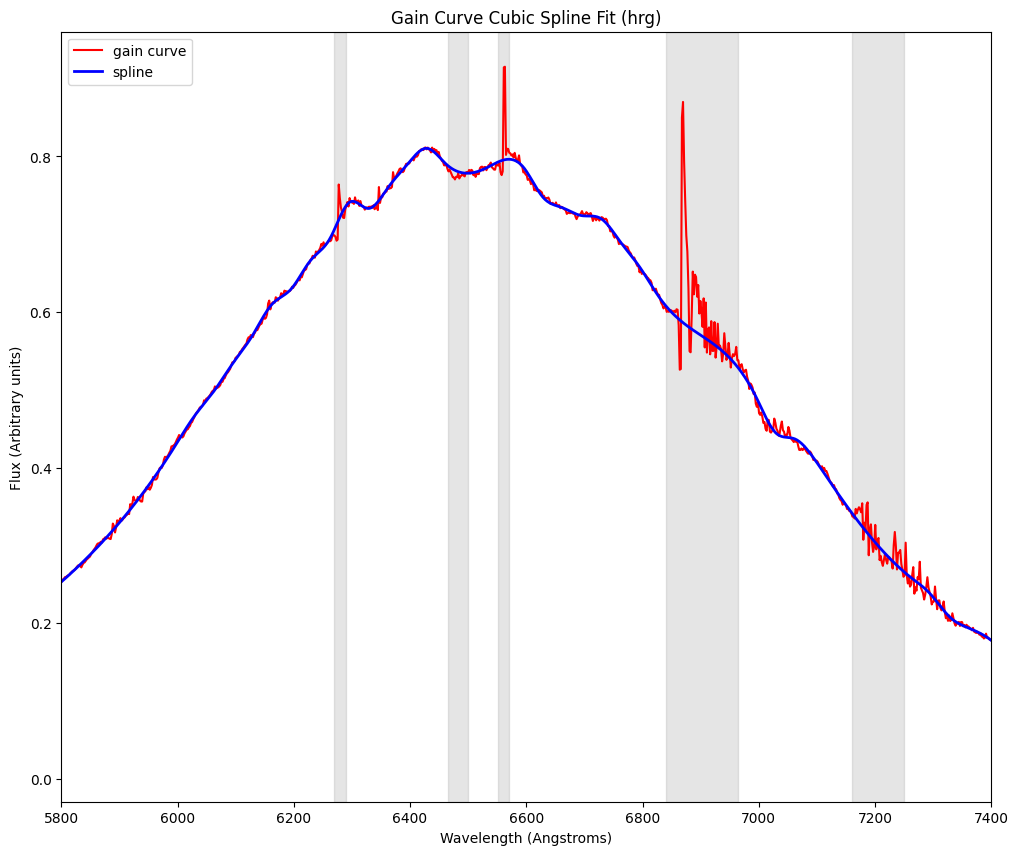

In [41]:
from scipy.interpolate import LSQUnivariateSpline

exclude_regions = [
    (6270, 6290),
    (6465, 6500),
    (6552, 6570),
    (6840, 6965),
    (7160, 7250)
]

mask = np.ones_like(wave_grid, dtype=bool)

for lo, hi in exclude_regions:
    mask &= (wave_grid < lo) | (wave_grid > hi)

knots = np.linspace(wave_grid.min()+200, wave_grid.max()-200, 45)

for lo, hi in exclude_regions:
    knots = knots[(knots < lo) | (knots > hi)]

spline = LSQUnivariateSpline(wave_grid[mask], gain[mask], t=knots, k=3)
gain_smooth = spline(wave_grid)

plt.figure(figsize=(12,10))
plt.plot(wave_grid, gain, color='red', label='gain curve')
plt.plot(wave_grid, gain_smooth, color='blue', linewidth=2, label='spline')

for lo, hi in exclude_regions:
    plt.axvspan(lo, hi, color='gray', alpha=0.2)

plt.xlim(5800, 7400)
plt.xlabel('Wavelength (Angstroms)')
plt.ylabel('Flux (Arbitrary units)')
plt.title(f'Gain Curve Cubic Spline Fit ({filter})')
plt.legend()
plt.show()

# Use NIST Database Wavelengths for Various Elements to Identify Spectral Features

## Get spectral line info from nist_lines.csv

You will have to put the nist_lines.csv file into a directory of your choice 
then specify the location with nistpath

In [18]:
# Import and read in nist_lines.csv

nistpath = os.path.expanduser('~/gdrive/My Drive/PHYS491-user/Grism_Workbench/')

df = pd.read_csv(nistpath+'nist_lines.csv')
# print(df[['Element', 'Wavelength', 'Name']])
# sort the df by wavelength:
df = df.sort_values(by=['Wavelength'])
print(df[['Element', 'Wavelength', 'Name']])
# print # of transitions loaded:
print(f"Number of transitions loaded: {len(df)}")

   Element  Wavelength               Name
0      C I  5800.59993   C I (5800.59993)
19   Fe II  5807.66610  Fe II (5807.6661)
45    S II  5819.23800    S II (5819.238)
36    He I  5875.61397  He I (5875.61397)
37    He I  5875.61484  He I (5875.61484)
38    He I  5875.62510  He I (5875.62510)
39    He I  5875.64036  He I (5875.64036)
20   Fe II  5885.01440  Fe II (5885.0144)
41    Na I  5889.95094  Na I (5889.95094)
42    Na I  5895.92424  Na I (5895.92424)
21   Fe II  5902.82310  Fe II (5902.8231)
22   Fe II  5914.54700  Fe II (5914.5470)
23   Fe II  5961.70550  Fe II (5961.7055)
1      C I  5969.33151   C I (5969.33151)
2      C I  6001.12300     C I (6001.123)
3      C I  6006.01200     C I (6006.012)
4      C I  6013.16600     C I (6013.166)
5      C I  6013.25180    C I (6013.2518)
6      C I  6016.44870    C I (6016.4487)
43     S I  6052.70400     S I (6052.704)
46    S II  6286.34600    S II (6286.346)
47    S II  6286.95100    S II (6286.951)
48    S II  6305.47900    S II (63

In [17]:
# Define the wavelengths and names to replace (He has a bunch of stuff close together)
he_lines = ['He I (5875.61397)', 'He I (5875.61484)', 'He I (5875.6251)', 'He I (5875.64036)']
blend_name = 'He I (5875.621)'
blend_wavelength = 5875.621

# Update 'Name' and 'Wavelength' for specified He I lines
df.loc[df['Name'].isin(he_lines), 'Name'] = blend_name
df.loc[df['Name'] == blend_name, 'Wavelength'] = blend_wavelength

# Remove duplicates
df = df.drop_duplicates(subset=['Element', 'Wavelength', 'Name'])

# Print the updated DataFrame
pd.set_option('display.max_rows', None)  # Show all rows
print(df[['Element', 'Wavelength', 'Name']])

# Print the number of transitions loaded
print(f"Number of transitions loaded: {len(df)}")

   Element  Wavelength               Name
0      C I  5800.59993   C I (5800.59993)
19   Fe II  5807.66610  Fe II (5807.6661)
45    S II  5819.23800    S II (5819.238)
36    He I  5875.62100    He I (5875.621)
38    He I  5875.62510  He I (5875.62510)
20   Fe II  5885.01440  Fe II (5885.0144)
41    Na I  5889.95094  Na I (5889.95094)
42    Na I  5895.92424  Na I (5895.92424)
21   Fe II  5902.82310  Fe II (5902.8231)
22   Fe II  5914.54700  Fe II (5914.5470)
23   Fe II  5961.70550  Fe II (5961.7055)
1      C I  5969.33151   C I (5969.33151)
2      C I  6001.12300     C I (6001.123)
3      C I  6006.01200     C I (6006.012)
4      C I  6013.16600     C I (6013.166)
5      C I  6013.25180    C I (6013.2518)
6      C I  6016.44870    C I (6016.4487)
43     S I  6052.70400     S I (6052.704)
46    S II  6286.34600    S II (6286.346)
47    S II  6286.95100    S II (6286.951)
48    S II  6305.47900    S II (6305.479)
49    S II  6312.66600    S II (6312.666)
54   Si II  6347.11000    Si II (6

## Plot Spectral Line Info on Calibrated Spectrum and Locate Features

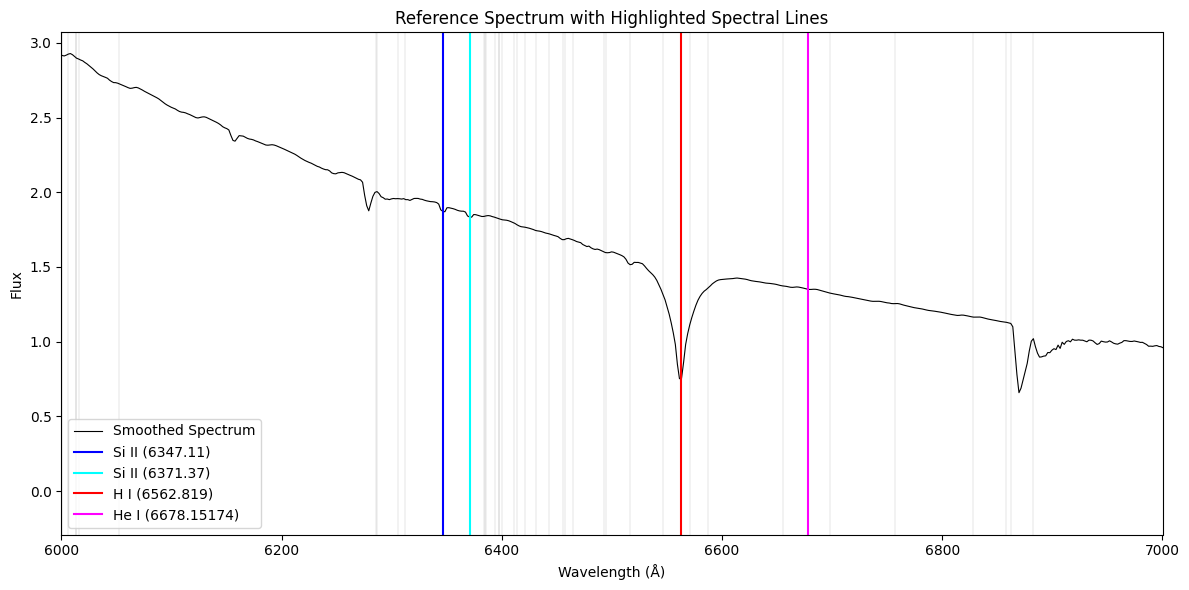

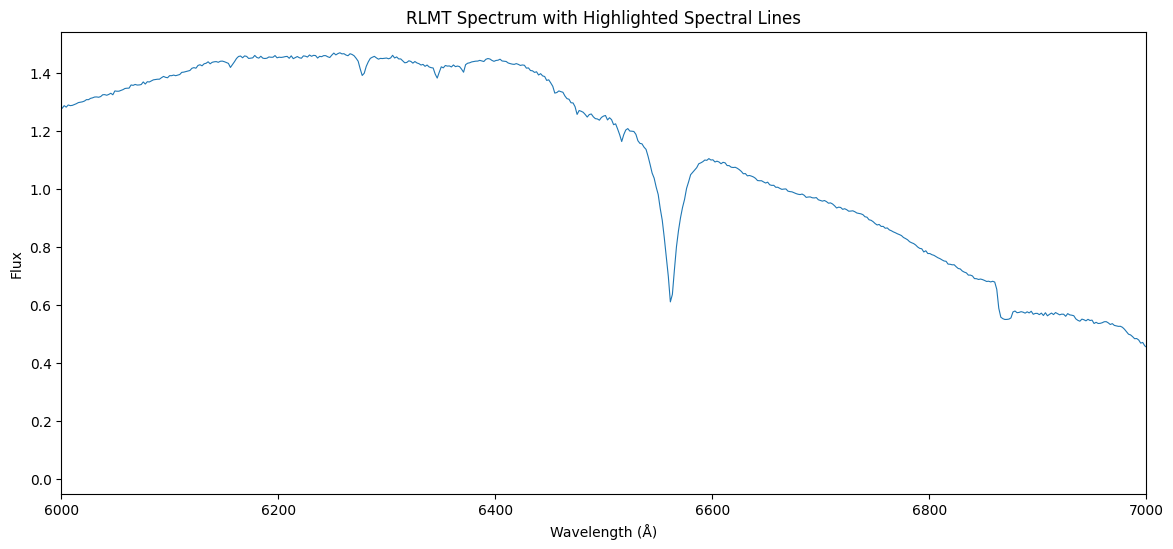

In [59]:
z = (rv*u.km/u.s+radial_vel_correction)/c # For wavelength correction

# Selected line names and their highlight colors
# selected_names = ['He I (5875.621)', 'Si II (6347.11)', 'Si II (6371.37)',
#                   'Fe II (6517.0293)', 'H I (6562.819)', 'He I (6678.15174)']
selected_names = ['Si II (6347.11)', 'Si II (6371.37)',
                  'H I (6562.819)', 'He I (6678.15174)']
selected_colors = ['blue', 'cyan', 'red', 'magenta']

# Optional: apply a smoothing if you want, or leave raw
smoothed_spectrum = np.convolve(flux_ref_interp, np.ones(3)/3, mode='valid')
x_smoothed = wave_grid[1:-1]

plt.figure(figsize=(12, 6))

# Plot spectrum
# plt.plot(calibrated_spectrum, spectrum_out, color='gray', alpha=0.4, linewidth=0.5)
plt.plot(x_smoothed, smoothed_spectrum, color='black', linewidth=0.8, label='Smoothed Spectrum')

# Plot all lines from df as faint black vertical lines
for _, row in df.iterrows():
    plt.axvline(x=row['Wavelength'] * (1 + z), color='k', linestyle='-', linewidth=0.25, alpha=0.3)

# Highlight selected lines
for i, name in enumerate(selected_names):
    line = df[df['Name'] == name]
    if not line.empty:
        wavelength = line['Wavelength'].values[0] * (1 + z)
        plt.axvline(x=wavelength, color=selected_colors[i], linestyle='-', linewidth=1.5, alpha=1.0, label=name)

# Include any additional lines you think are apparent from the spectral atlas and/or NIST
    # Spectral atlas: https://drive.google.com/drive/folders/18H0q-meNZUt-ChXLOdYd9F55-uaTUqEE
    # NIST: https://physics.nist.gov/PhysRefData/ASD/lines_form.html
# plt.axvline(x = 6137.691*(1 + z), color = 'magenta', linewidth = 1, label = 'Fe I (6137.691)')
# plt.axvline(x = 6230.7219*(1 + z), color = 'red', linewidth = 1, label = 'Fe I (6230.7219)')

plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux")
plt.xlim(6000, 7000)
plt.ylim(np.min(smoothed_spectrum) - np.std(smoothed_spectrum), np.median(smoothed_spectrum + 2*np.std(smoothed_spectrum)))
plt.title("Reference Spectrum with Highlighted Spectral Lines")
# plt.legend(bbox_to_anchor=(1.05, 1), loc='lower left')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

plt.figure(figsize = (14,6))
plt.plot(wave_grid, flux_data_interp,linewidth = 0.8)
plt.xlim(6000, 7000)
plt.title("RLMT Spectrum with Highlighted Spectral Lines")
plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux")
plt.show()


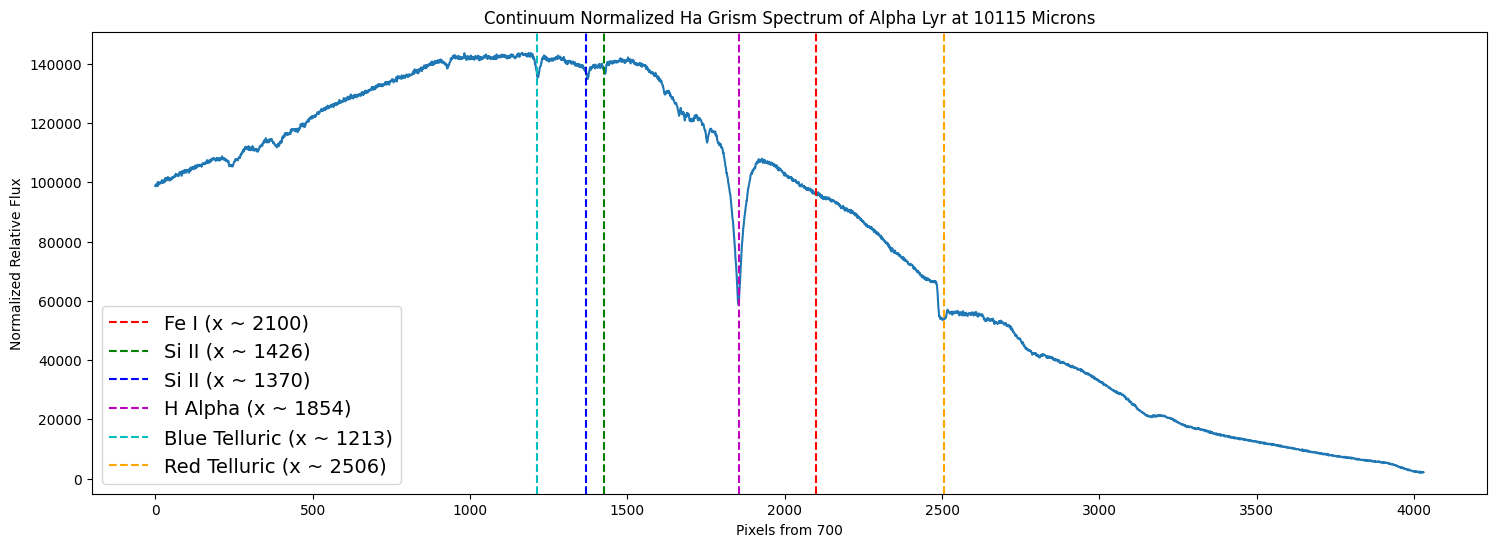

In [69]:
# Use this as a plot to find a rough pixel location of features to use as a guess point then actually fit those features in the code below

shift = -565

plt.figure(figsize=(18, 6))
plt.plot(pixels, fluxes)
plt.title(f'Continuum Normalized Ha Grism Spectrum of {target_name} at 10115 Microns')
plt.xlabel('Pixels from 700')
plt.ylabel('Normalized Relative Flux')
# Plot vertical lins at pixel locations of spectral features
plt.axvline(x=2665 + shift, color='r', linestyle='--', label = f'Fe I (x ~ {2665 + shift})')
plt.axvline(x=1991 + shift, color='g', linestyle='--', label = f'Si II (x ~ {1991 + shift})')
plt.axvline(x=1935 + shift, color='b', linestyle='--', label = f'Si II (x ~ {1935 + shift})')
plt.axvline(x=2419 + shift, color='m', linestyle='--', label = f'H Alpha (x ~ {2419 + shift})')
# plt.axvline(x=2183 + shift, color='y', linestyle='--', label = f'Fe II (x ~ {2183 + shift})')
# plt.axvline(x=2318 + shift, color='k', linestyle='--', label = f'Fe II (x ~ {2318 + shift})')

# Make a list to iterate over (match to axvline placements)
pixel_guesses = [1935 + shift, 1991 + shift, 2665 + shift, 2419 + shift] # Do not include relluric lines in this list

plt.axvline(x=1778 + shift, color='c', linestyle='--', label = f'Blue Telluric (x ~ {1778 + shift})')
plt.axvline(x=3071 + shift, color='orange', linestyle='--', label = f'Red Telluric (x ~ {3071 + shift})')

telluric_guesses = [1778 + shift, 3071 + shift] 

# plt.xlim(660,3500)
# Set vertical limits
# plt.ylim(0.5, 1.01)
plt.legend(fontsize = 14, loc = 'lower left')
plt.show()

# Fit Lines to Spectral Features

In [73]:
# Here are the functions to fit features

def gaussian(x, a, x0, sigma, offset):
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2)) + offset

def fit_feature(spec_cont, peak_center, width, height, width_guess=None):
    xmin, xmax = peak_center - width, peak_center + width
    peaks, _ = find_peaks(spec_cont[xmin:xmax], height=height, distance=10)
    if width_guess is None:
        width_guess = width
    x = np.arange(xmin, xmax)
    y = spec_cont[xmin:xmax]
    p0 = [height, peak_center, width_guess, 1]
    popt, pcov = curve_fit(gaussian, x, y, p0=p0)

    # Plot
    plt.figure(figsize=(15,5))
    plt.plot(x, y)
    plt.plot(x, gaussian(x, *popt))
    plt.title('Fit of absorption line')
    plt.xlabel('Pixel')
    plt.ylabel('Normalized intensity')
    plt.show()
    return popt



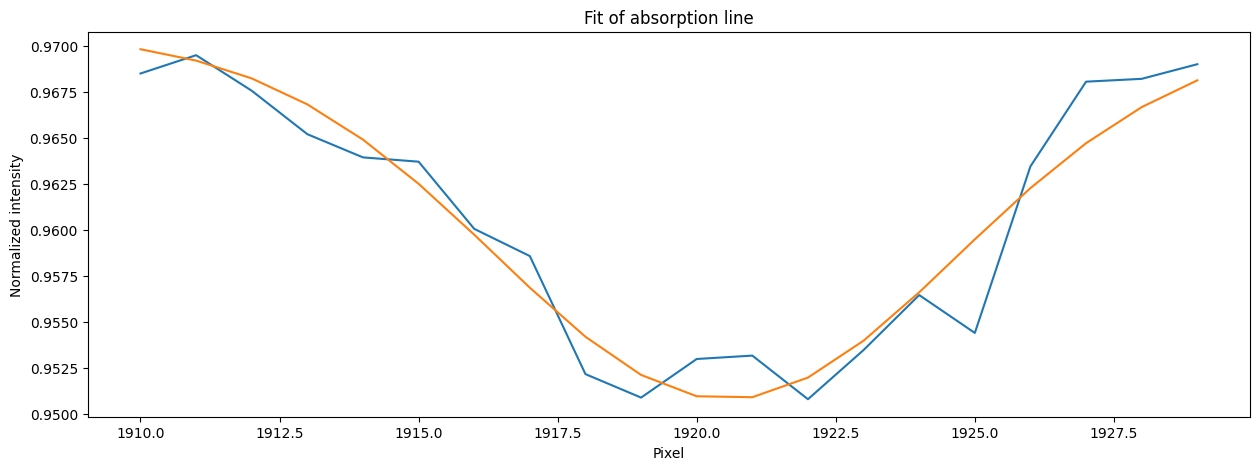

FWHM: 9.76
Peak center: 1920.5441721139543


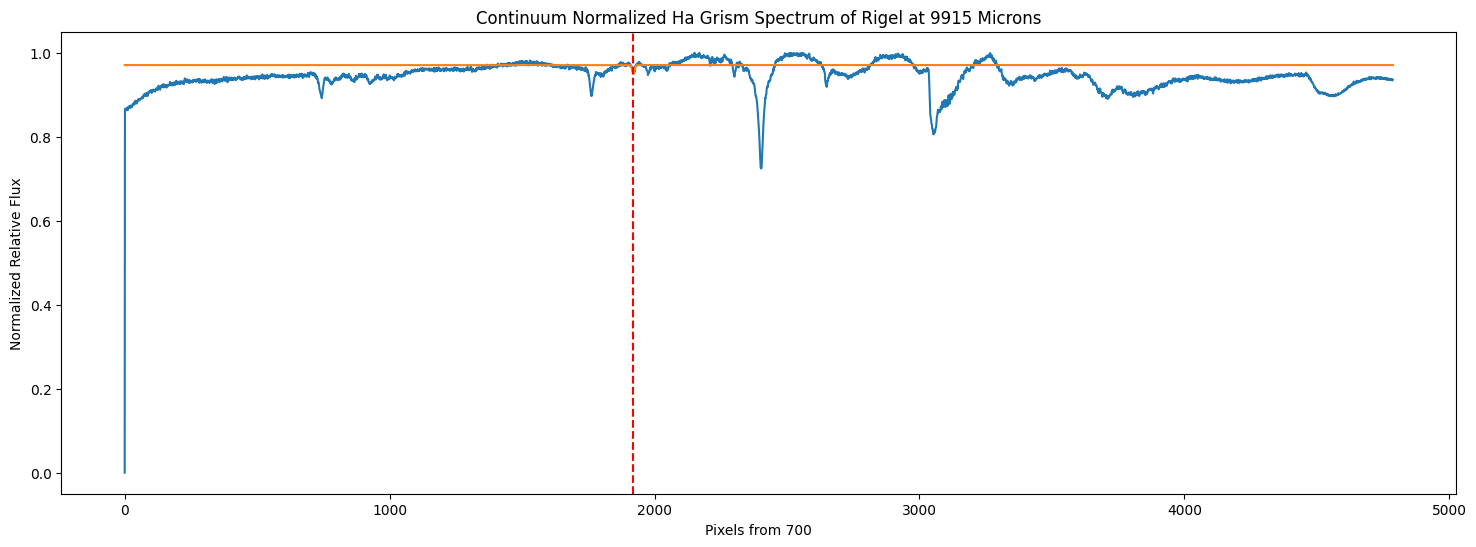

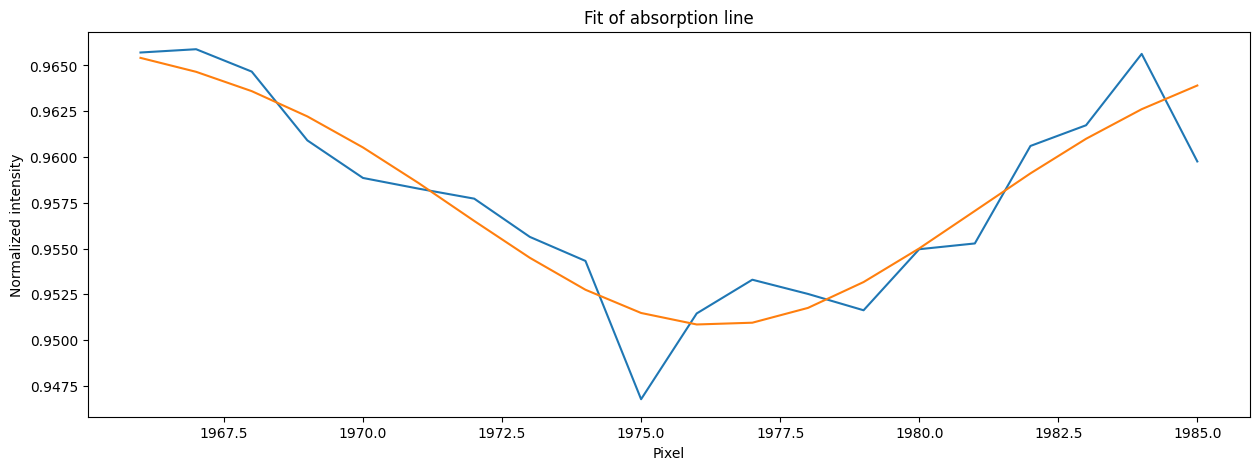

FWHM: 10.92
Peak center: 1976.368553452646


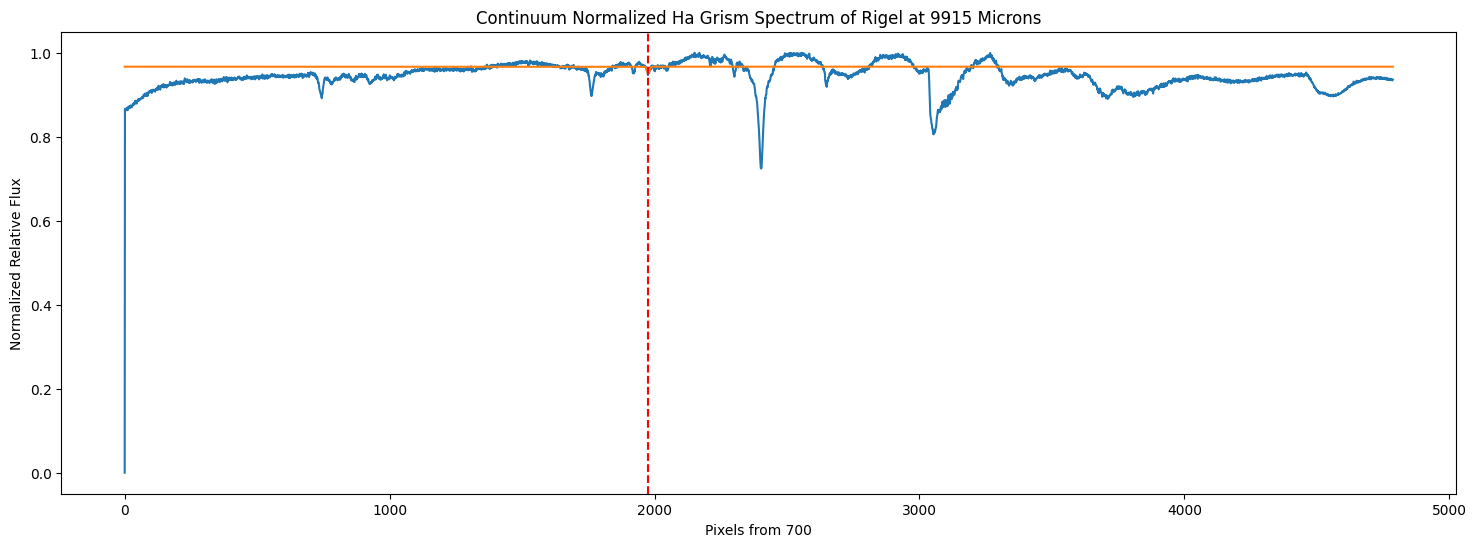

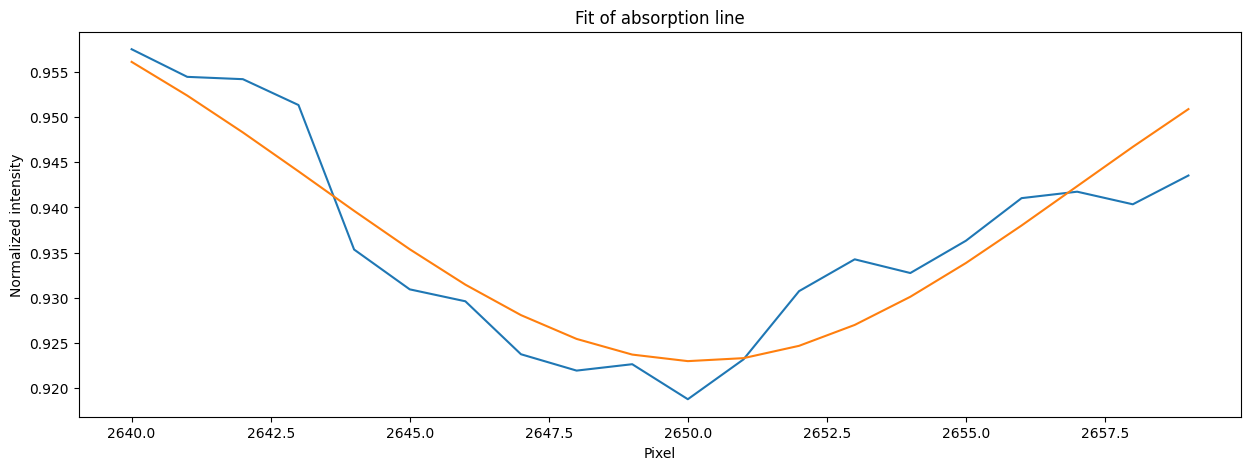

FWHM: 16.02
Peak center: 2650.1878394941355


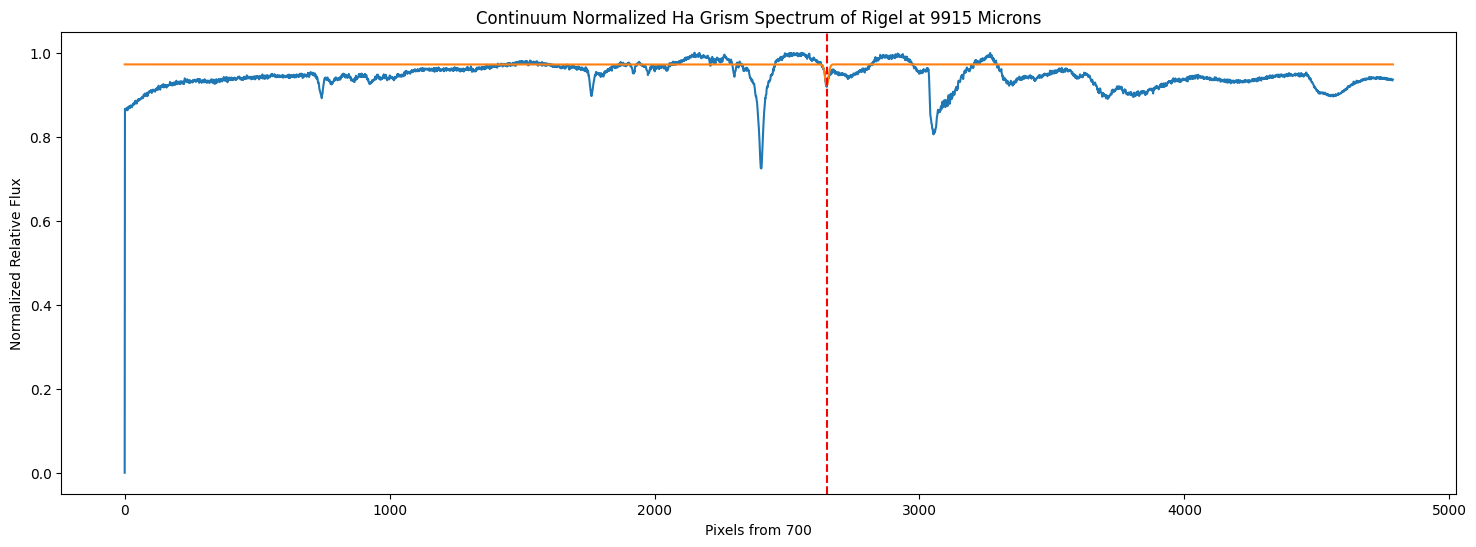

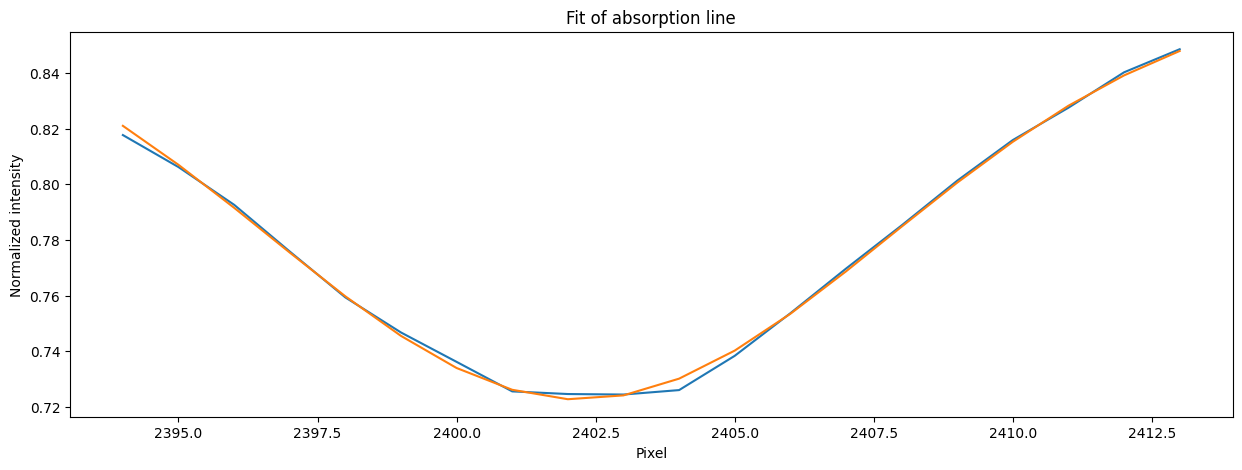

FWHM: 13.02
Peak center: 2402.2121921943926


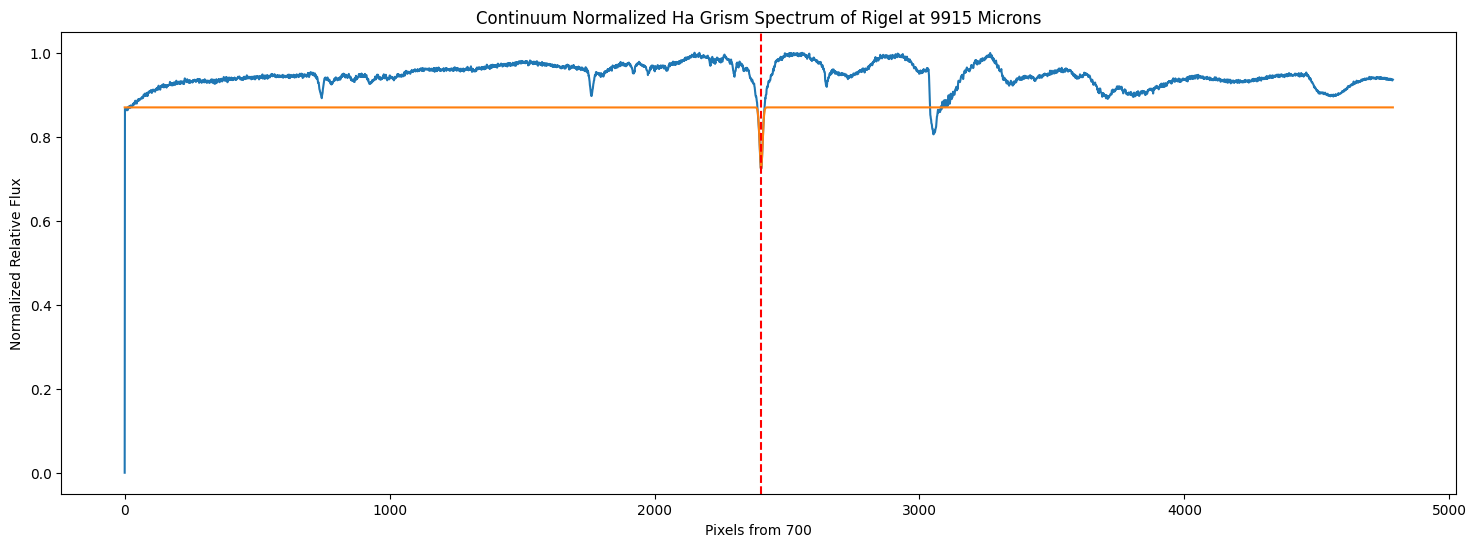

In [74]:
peak_centers = []

for pixel_guess in pixel_guesses:
    popt = fit_feature(norm_spectrum, pixel_guess, 10, -1)
    fwhm = 2 * np.sqrt(2 * np.log(2)) * popt[2]
    print(f"FWHM: {fwhm:.2f}")
    print(f"Peak center: {popt[1]}")

    peak_centers.append(popt[1])

    plt.figure(figsize=(18, 6))
    plt.plot(norm_spectrum)
    plt.plot(gaussian(np.arange(norm_spectrum.shape[0]), *popt))
    plt.title('Continuum Normalized Ha Grism Spectrum of Rigel at 9915 Microns')
    plt.xlabel('Pixels from 700')
    plt.ylabel('Normalized Relative Flux')
    plt.axvline(x=popt[1], color='r', linestyle='--')
    plt.show()

peak_centers.sort()

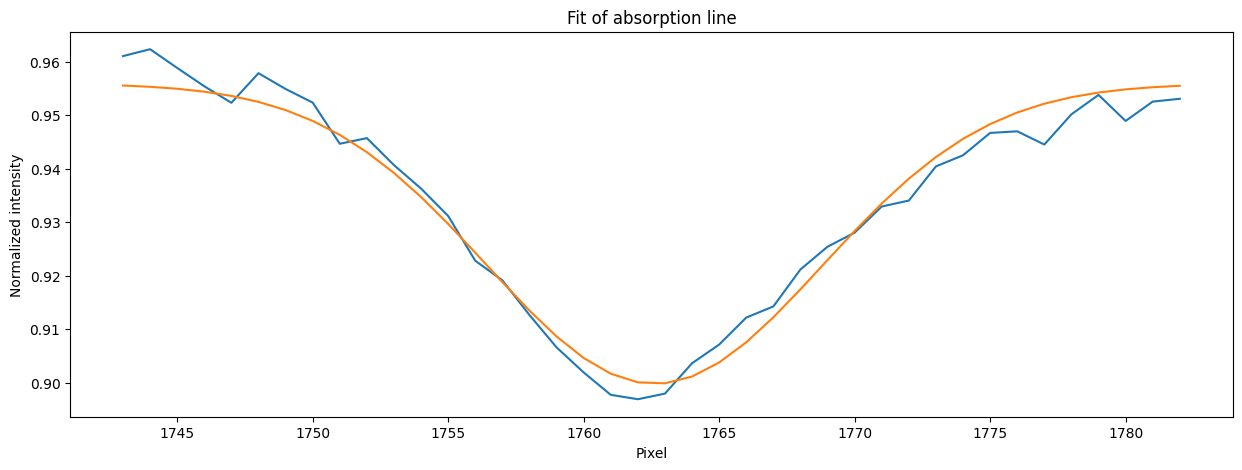

FWHM: 13.02
Peak center: 1762.6246019799426


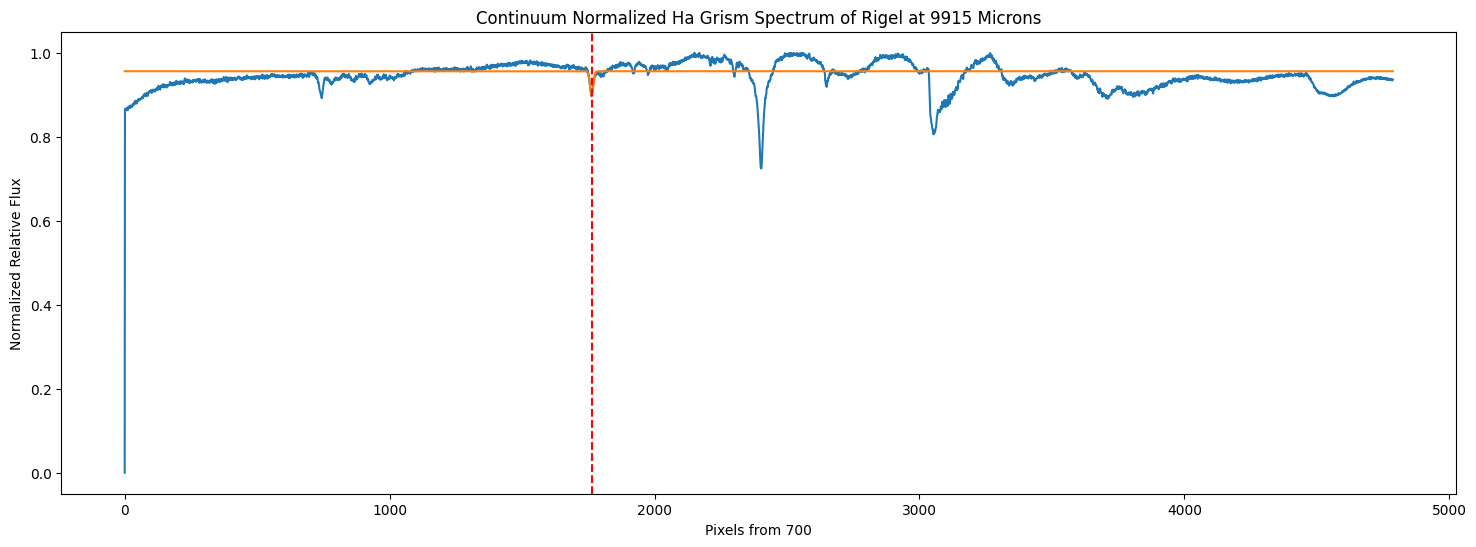

In [75]:
# Fit the blue telluric features

telluric_guesses.sort()

bt_popt = fit_feature(norm_spectrum, telluric_guesses[0], 20, -1)

fwhm = 2 * np.sqrt(2 * np.log(2)) * popt[2]
print(f"FWHM: {fwhm:.2f}")
print(f"Peak center: {bt_popt[1]}")

plt.figure(figsize=(18, 6))
plt.plot(norm_spectrum)
plt.plot(gaussian(np.arange(norm_spectrum.shape[0]), *bt_popt))
plt.title('Continuum Normalized Ha Grism Spectrum of Rigel at 9915 Microns')
plt.xlabel('Pixels from 700')
plt.ylabel('Normalized Relative Flux')
plt.axvline(x=bt_popt[1], color='r', linestyle='--')
plt.show()

In [76]:
# Make a list of the wavelengths in the selected_names list

wavelengths = [float(name.split('(')[-1].rstrip(')')) for name in selected_names]

print(wavelengths)

[6347.11, 6371.37, 6562.819, 6678.15174]


In [77]:
# Apply wavelength correction due to the Earth's motion and target's recessional velocity

corrected_wavelengths = []
n_air = 1.000293

for entry in wavelengths:
    corrected_wavelengths.append(float(np.round(entry*wavelength_correction*n_air,3)))

In [78]:
# Append the wavelength list with telluric features

btel_peak_center = bt_popt[1]
btel_wavelength = 6280.4
peak_centers.append(btel_peak_center)
corrected_wavelengths.append(btel_wavelength)

rtel_peak_center = telluric_x
rtel_wavelength = 6873.1
peak_centers.append(rtel_peak_center)
corrected_wavelengths.append(rtel_wavelength)

## Check everything lines up with plots in pixel space

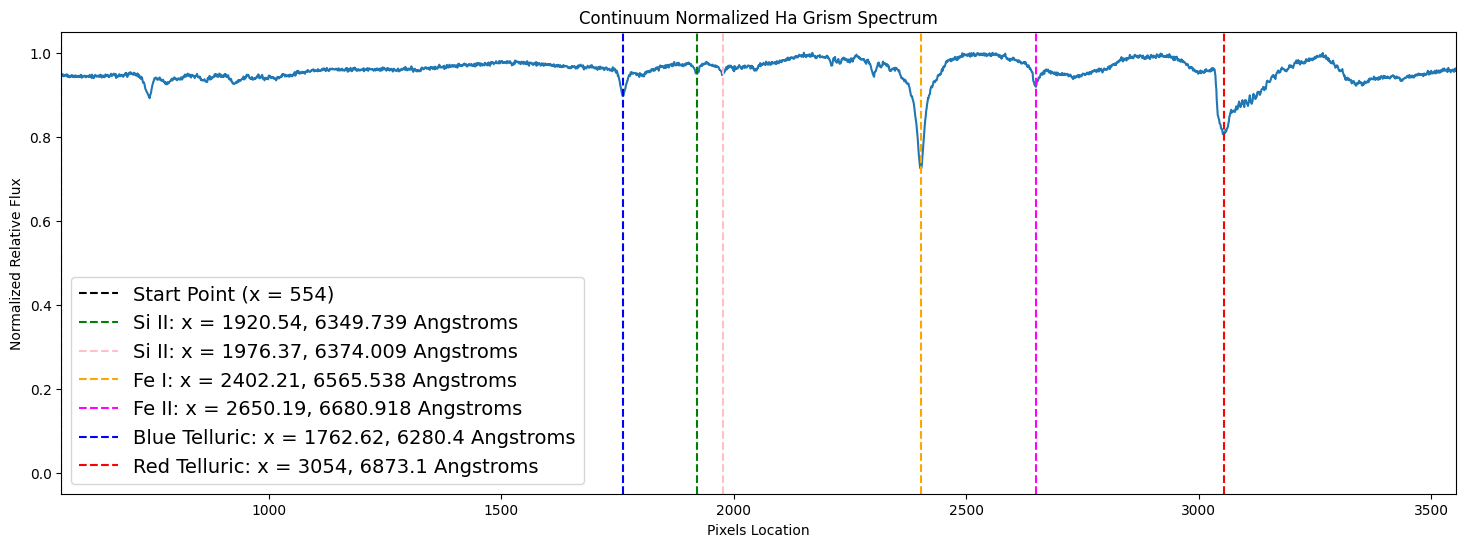

In [79]:
#Plot everything in pixel space to confirm

plt.figure(figsize=(18, 6))
plt.plot(norm_spectrum)
# plt.scatter(telluric_x,norm_spectrum[int(telluric_x)],color = 'r',marker = 'x', label = 'Telluric Line')
plt.axvline(x = telluric_x - 2500, color = 'black', linestyle = '--', label = f'Start Point (x = {telluric_x-2500})')

plt.axvline(x = peak_centers[0], color = 'green', linestyle = '--', label = f'Si II: x = {np.round(peak_centers[0],2)}, {corrected_wavelengths[0]} Angstroms')
plt.axvline(x = peak_centers[1], color = 'pink', linestyle = '--', label = f'Si II: x = {np.round(peak_centers[1],2)}, {corrected_wavelengths[1]} Angstroms')
plt.axvline(x = peak_centers[2], color = 'orange', linestyle = '--', label = f'Fe I: x = {np.round(peak_centers[2],2)}, {corrected_wavelengths[2]} Angstroms')
plt.axvline(x = peak_centers[3], color = 'magenta', linestyle = '--', label = f'Fe II: x = {np.round(peak_centers[3],2)}, {corrected_wavelengths[3]} Angstroms')
# plt.axvline(x = peak_centers[4], color = 'cyan', linestyle = '--', label = f'Ha: x = {np.round(peak_centers[4],2)}, {corrected_wavelengths[4]} Angstroms')
# plt.axvline(x = peak_centers[5], color = 'purple', linestyle = '--', label = f'Na I: x = {np.round(peak_centers[5],2)}, {corrected_wavelengths[5]} Angstroms')

plt.axvline(x = peak_centers[4], color = 'blue', linestyle = '--', label = f'Blue Telluric: x = {np.round(peak_centers[4],2)}, {corrected_wavelengths[4]} Angstroms')
plt.axvline(x = peak_centers[5], color = 'red', linestyle = '--', label = f'Red Telluric: x = {np.round(peak_centers[5],2)}, {corrected_wavelengths[5]} Angstroms')

plt.title('Continuum Normalized Ha Grism Spectrum')
plt.xlabel('Pixels Location')
plt.ylabel('Normalized Relative Flux')
plt.xlim(telluric_x-2500, telluric_x+500)
plt.legend(fontsize = 14, loc = 'lower left')
plt.show()


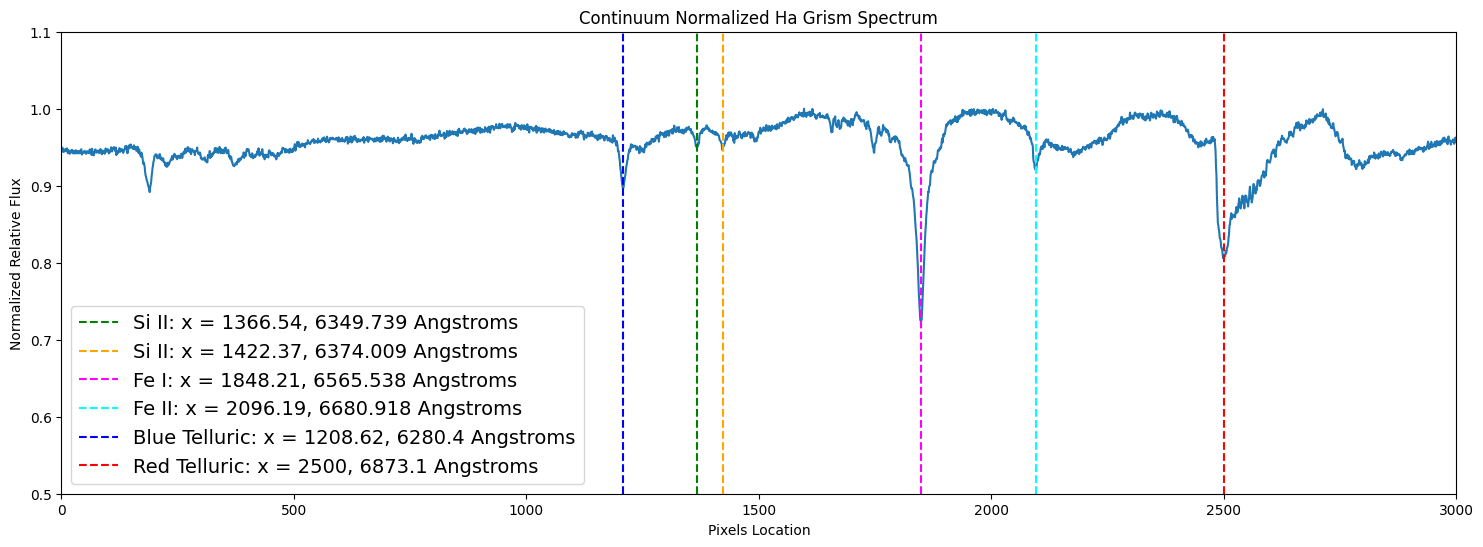

In [80]:
# Set the red telluric point as an anchor point at 2500 pixels for an effective extraction box

start_point = int(telluric_x - 2500)

extract_spectrum = norm_spectrum[start_point:]

extract_peak_centers = []

for entry in peak_centers:
    extract_peak_centers.append(entry-start_point)

#Plot everything in pixel space now for extract

plt.figure(figsize=(18, 6))
plt.plot(norm_spectrum[start_point:])
# plt.scatter(telluric_x-start_point,norm_spectrum[start_point:][int(telluric_x-start_point)],color = 'r',marker = 'x', label = 'Telluric Line')

plt.axvline(x = extract_peak_centers[0], color = 'green', linestyle = '--', label = f'Si II: x = {np.round(extract_peak_centers[0],2)}, {corrected_wavelengths[0]} Angstroms')
plt.axvline(x = extract_peak_centers[1], color = 'orange', linestyle = '--', label = f'Si II: x = {np.round(extract_peak_centers[1],2)}, {corrected_wavelengths[1]} Angstroms')
plt.axvline(x = extract_peak_centers[2], color = 'magenta', linestyle = '--', label = f'Fe I: x = {np.round(extract_peak_centers[2],2)}, {corrected_wavelengths[2]} Angstroms')
plt.axvline(x = extract_peak_centers[3], color = 'cyan', linestyle = '--', label = f'Fe II: x = {np.round(extract_peak_centers[3],2)}, {corrected_wavelengths[3]} Angstroms')
# plt.axvline(x = extract_peak_centers[4], color = 'yellow', linestyle = '--', label = f'Fe II: x = {np.round(extract_peak_centers[4],2)}, {corrected_wavelengths[4]} Angstroms')
# plt.axvline(x = extract_peak_centers[5], color = 'purple', linestyle = '--', label = f'Ha: x = {np.round(extract_peak_centers[5],2)}, {corrected_wavelengths[5]} Angstroms')

plt.axvline(x = extract_peak_centers[4], color = 'blue', linestyle = '--', label = f'Blue Telluric: x = {np.round(extract_peak_centers[4],2)}, {corrected_wavelengths[4]} Angstroms')
plt.axvline(x = extract_peak_centers[5], color = 'red', linestyle = '--', label = f'Red Telluric: x = {np.round(extract_peak_centers[5],2)}, {corrected_wavelengths[5]} Angstroms')

plt.ylim(0.5,1.1)
plt.title('Continuum Normalized Ha Grism Spectrum')
plt.xlabel('Pixels Location')
plt.ylabel('Normalized Relative Flux')
plt.xlim(0,3000)
plt.legend(fontsize = 14, loc = 'lower left')
plt.show()


In [81]:
extract_peak_centers.sort()
wavelengths.sort()
corrected_wavelengths.sort()

print(f"Pixel Peak Centers: {extract_peak_centers}")
print(f'Wavelengths: {wavelengths}')
print(f'Corrected + Telluric Wavelengths: {corrected_wavelengths}')

Pixel Peak Centers: [np.float64(1208.6246019799426), np.float64(1366.5441721139543), np.float64(1422.368553452646), np.float64(1848.2121921943926), np.float64(2096.1878394941355), 2500]
Wavelengths: [6347.11, 6371.37, 6562.819, 6678.15174]
Corrected + Telluric Wavelengths: [6280.4, 6349.739, 6374.009, 6565.538, 6680.918, 6873.1]


# Derive Wavelength Calibration


=== Fit Report ===
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 9
    # data points      = 6
    # variables        = 3
    chi-square         = 0.19406903
    reduced chi-square = 0.06468968
    Akaike info crit   = -14.5878050
    Bayesian info crit = -15.2125266
[[Variables]]
    a:  1.9779e-05 +/- 6.5108e-07 (3.29%) (init = 1e-06)
    b:  0.38553341 +/- 0.00240846 (0.62%) (init = 0)
    c:  5785.67509 +/- 2.10669227 (0.04%) (init = 6469.773)
[[Correlations]] (unreported correlations are < 0.100)
    C(a, b) = -0.9955
    C(b, c) = -0.9943
    C(a, c) = +0.9808

R^2 = 0.999999

Pixel location of H-alpha = 1841.700
New solution λ at Hα pixel  = 6562.8000 Å
Old solution λ at Hα pixel  = 6559.5995 Å
Difference (new - old)       = 3.2005 Å
Uncertainty at Hα pixel     = ±0.1767 Å


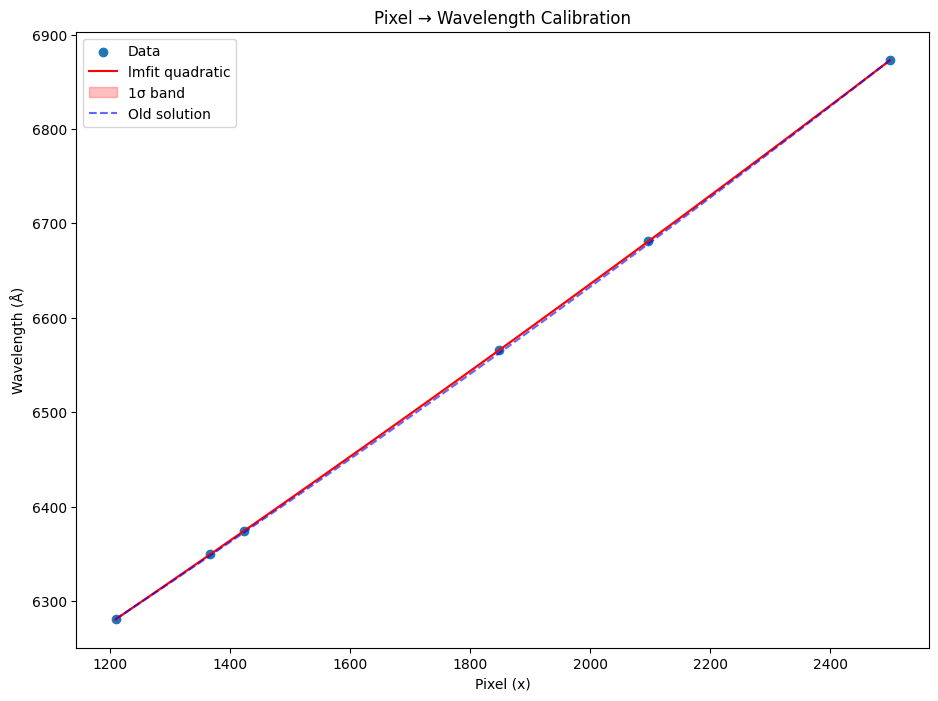

In [82]:
from lmfit import Minimizer, Parameters, report_fit

# ---------------------------------------------------------
# Data
# ---------------------------------------------------------
xdata = np.asarray(extract_peak_centers)
ydata = np.asarray(corrected_wavelengths)

# Pixel grid for visualization
low = int(np.min(xdata))
high = int(np.max(xdata))
xplot = np.linspace(low, high, high-low+1)

# ---------------------------------------------------------
# lmfit model
# ---------------------------------------------------------
def residual(params, x, data):
    a = params['a'].value
    b = params['b'].value
    c = params['c'].value
    return a*x**2 + b*x + c - data

params = Parameters()
params.add('a', value=1e-6)
params.add('b', value=0.0)
params.add('c', value=np.median(ydata))

mini = Minimizer(residual, params, fcn_args=(xdata, ydata))
result = mini.minimize()

print("\n=== Fit Report ===")
report_fit(result)

a = result.params['a'].value
b = result.params['b'].value
c = result.params['c'].value

# Best-fit curve
yfit = a*xplot**2 + b*xplot + c

# ---------------------------------------------------------
# R^2 calculation
# ---------------------------------------------------------
resid = ydata - (a*xdata**2 + b*xdata + c)
ss_res = np.sum(resid**2)
ss_tot = np.sum((ydata - np.mean(ydata))**2)
r2 = 1 - ss_res/ss_tot
print(f"\nR^2 = {r2:.6f}")

# ---------------------------------------------------------
# Parameter covariance → uncertainty propagation
# ---------------------------------------------------------
cov = result.covar
if cov is None:
    print("WARNING: covariance matrix unavailable — uncertainties cannot be computed.")
else:
    # Build Jacobian for every pixel in xplot
    J = np.vstack([xplot**2, xplot, np.ones_like(xplot)])  # (3,N)
    var_y = np.einsum('ij,jk,ik->i', J.T, cov, J.T)
    sigma_y = np.sqrt(np.maximum(var_y,0))

# ---------------------------------------------------------
# OLD wavelength solution
# ---------------------------------------------------------
def old_solution(x):
    return 5809.515939 + 0.3564304348*x + 0.00002760895652*x**2

# ---------------------------------------------------------
# FIND PIXEL COORDINATE OF H-alpha
# new solution solves a*x^2 + b*x + (c - 6562.8) = 0
# ---------------------------------------------------------
Hα = 6562.8
coeffs = [a, b, c - Hα]
roots = np.roots(coeffs)

# pick the real root inside pixel range
x_Ha = roots[np.isreal(roots)].real
x_Ha = x_Ha[(x_Ha>=low) & (x_Ha<=high)]
if len(x_Ha) == 0:
    print("Could not determine x-pixel for H-alpha inside fit range.")
    x_Ha = None
else:
    x_Ha = float(x_Ha[0])
    print(f"\nPixel location of H-alpha = {x_Ha:.3f}")

    # wavelength from both solutions
    new_λ_Ha = a*x_Ha**2 + b*x_Ha + c
    old_λ_Ha = old_solution(x_Ha)
    diff_Ha = new_λ_Ha - old_λ_Ha

    print(f"New solution λ at Hα pixel  = {new_λ_Ha:.4f} Å")
    print(f"Old solution λ at Hα pixel  = {old_λ_Ha:.4f} Å")
    print(f"Difference (new - old)       = {diff_Ha:.4f} Å")

    # uncertainty at that pixel
    if cov is not None:
        J_Ha = np.array([x_Ha**2, x_Ha, 1.0])
        var_Ha = J_Ha.T @ cov @ J_Ha
        sigma_Ha = np.sqrt(np.maximum(var_Ha, 0))
        print(f"Uncertainty at Hα pixel     = ±{sigma_Ha:.4f} Å")

# ---------------------------------------------------------
# Plotting
# ---------------------------------------------------------
plt.figure(figsize=(11,8))
plt.scatter(xdata, ydata, label='Data')
plt.plot(xplot, yfit, 'r', label='lmfit quadratic')

if cov is not None:
    plt.fill_between(xplot, yfit - sigma_y, yfit + sigma_y,
                     alpha=0.25, color='red', label='1σ band')

plt.plot(xplot, old_solution(xplot), 'b--', alpha=0.6, label='Old solution')
plt.xlabel('Pixel (x)')
plt.ylabel('Wavelength (Å)')
plt.title('Pixel → Wavelength Calibration')
plt.legend()
plt.show()

## (Optional): Check r-squared value

In [44]:
from sklearn.metrics import r2_score

poly_func = np.poly1d(p)  # Create a polynomial function from coefficients

# Generate predicted values
y_pred = poly_func(extract_peak_centers)

# Compute R-squared value
r_squared = r2_score(corrected_wavelengths, y_pred)

# Print results
print(f"Quadratic Coefficients: {p}")
print(f"Quadratic Equation: {poly_func}")
print(f"R^2: {r_squared:.8f}")

# Plot data and quadratic fit
plt.scatter(extract_peak_centers, corrected_wavelengths, label="Data Points", color='blue')
x_fit = np.linspace(min(extract_peak_centers), max(extract_peak_centers), 100)  # Smooth curve
y_fit = poly_func(x_fit)
plt.plot(x_fit, y_fit, label="Quadratic Fit", color='red')
plt.xlabel("Extract Peak Centers")
plt.ylabel("Corrected Wavelengths")
plt.legend()
plt.title("Quadratic Fit to Peak Centers vs. Wavelengths")
plt.show()


ModuleNotFoundError: No module named 'sklearn'

# Test New Wavelength Calibration

In [83]:
# This wavelength calibration is now based on your selected target

def new_wavelength_calibrate(spectra, a, b, c):
    spectrum = spectra
    pixel = np.arange(len(spectrum))
    wavelength = c + b * pixel + a * (pixel)**2
    calibrated_spectra = wavelength
    spectrum_out = spectrum
    plt.figure(figsize=(14, 6))
    plt.plot(wavelength[:len(spectrum)-10], spectrum[:len(spectrum)-10])

    plt.axvline(x = 6873.1, label='Red Telluric Line (6873.1 Angstroms)', color='red', linestyle='--')
    plt.axvline(x = 6280.4, label='Blue Telluric Line (6280.4 Angstroms)', color='blue', linestyle='--')
    plt.axvline(x = 6562.8*wavelength_correction*n_air, color = 'pink', linestyle = '--', label = f'H Alpha ({np.round(6562.8*wavelength_correction,3)} Angstroms)')

    plt.xlim(6200,7000)
    plt.ylim(np.min(spectrum) - np.std(spectrum), np.max(spectrum) + np.std(spectrum))
    plt.xlabel('Wavelength (Angstroms)')
    plt.ylabel('Intensity')
    plt.title('Calibrated Spectrum')
    plt.legend(loc = 'upper right')
    plt.show()
    return calibrated_spectra, spectrum_out

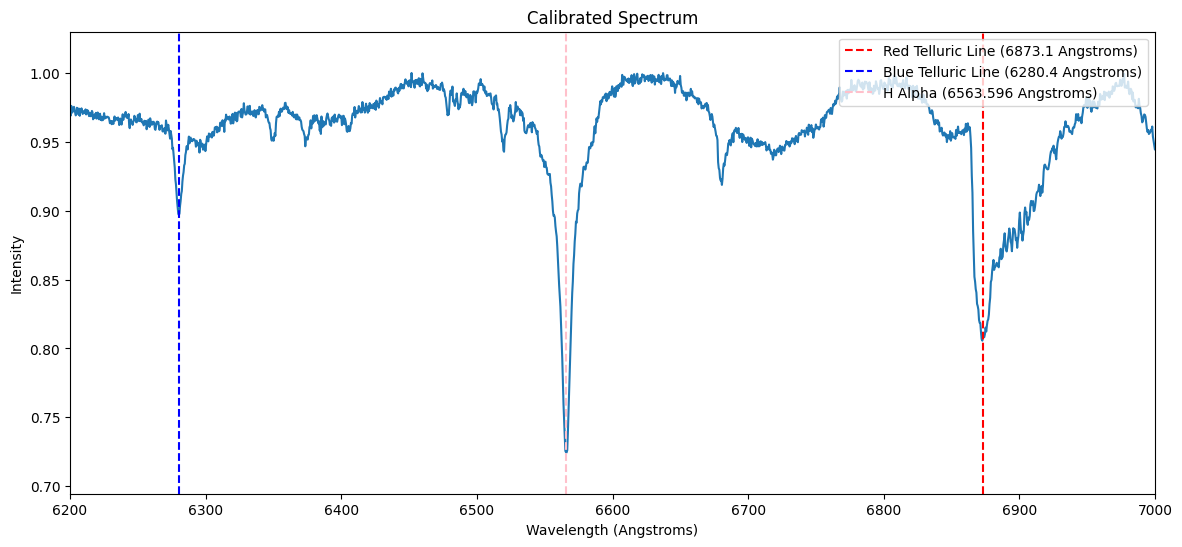

(array([5785.67509461, 5786.0606478 , 5786.44624055, ..., 7770.94055708,
        7771.49348139, 7772.04644526], shape=(4234,)),
 array([0.94952625, 0.9446436 , 0.94455004, ..., 0.93387157, 0.9352674 ,
        0.93594074], shape=(4234,), dtype=float32))

In [84]:
# See if Ha and the telluric lines match up!

new_wavelength_calibrate(norm_spectrum[telluric_x-2500:],a, b, c)

[1.97791450e-05 3.85533408e-01 5.78567509e+03]


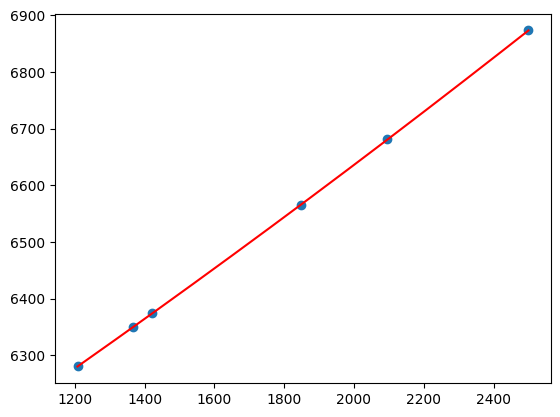

In [85]:
low = int(np.min(extract_peak_centers))
high = int(np.max(extract_peak_centers))
x = np.linspace(low, high, high-low)

fit = np.polyfit(extract_peak_centers, corrected_wavelengths, 2)
fitline = fit[0]*x**2 + fit[1]*x + fit[2]

# fit = np.polyfit(extract_peak_centers, corrected_wavelengths, 1)
# fitline = fit[0]*x + fit[1]

print(fit)

plt.scatter(extract_peak_centers, corrected_wavelengths)
plt.plot(x,fitline, color = 'red')

In [86]:
# Fit 2nd order polynomial to the peak centers
p = np.polyfit(extract_peak_centers, corrected_wavelengths, 2)
print(p)

[1.97791450e-05 3.85533408e-01 5.78567509e+03]


In [87]:
print(' a = '+str(np.round(p[0],9)))
print(' b = '+str(np.round(p[1],4)))
print(' c = '+str(np.round(p[2],4)))
print(f'Red Telluric: x = '+str(telluric_x))

 a = 1.9779e-05
 b = 0.3855
 c = 5785.6751
Red Telluric: x = 3054


# Flux Calibration

## Gain Curve Derivation

In [3]:
def load_stelib_spectrum(star_name, folder_path):
    """
    Load STELIB spectrum from a CSV file given a star name and folder path.

    Parameters:
    - star_name: str, like 'HD135722'
    - folder_path: str, full path to the folder in Google Drive containing the CSVs

    Returns:
    - df: Pandas DataFrame with columns 'wavelength' and 'flux'
    """
    # Build expected filename
    # Remove underscores in star names
    star_name = star_name.replace('_', '')
    for file in os.listdir(folder_path):
        if star_name in file and file.endswith('.csv'):
            file_path = os.path.join(folder_path, file)
            df = pd.read_csv(file_path)
            return df
    raise FileNotFoundError(f"No file found for star: {star_name}")

def match_and_interpolate(waves_data, flux_data, waves_ref_orig, flux_ref_orig, num_points=1000):
    """
    Safely interpolate both observed and reference spectra to a common grid.
    """
    # Copy reference arrays to avoid in-place modification
    waves_ref = np.copy(waves_ref_orig)
    flux_ref = np.copy(flux_ref_orig)

    # Ensure all arrays are 1D numpy arrays
    waves_data = np.array(waves_data).flatten()
    flux_data = np.array(flux_data).flatten()
    waves_ref = np.array(waves_ref).flatten()
    flux_ref = np.array(flux_ref).flatten()

    # Check that arrays match in size before interpolating
    if len(waves_data) != len(flux_data):
        raise ValueError(f"waves_data and flux_data lengths do not match: {len(waves_data)} vs {len(flux_data)}")
    if len(waves_ref) != len(flux_ref):
        raise ValueError(f"waves_ref and flux_ref lengths do not match: {len(waves_ref)} vs {len(flux_ref)}")

    # Determine overlapping wavelength range
    min_wave = max(np.min(waves_data), np.min(waves_ref))
    max_wave = min(np.max(waves_data), np.max(waves_ref))

    if min_wave >= max_wave:
        raise ValueError("No overlapping wavelength region between data and reference.")

    # Define common wavelength grid
    wave_grid = np.linspace(min_wave, max_wave, num_points)

    # Interpolate both spectra onto the same grid
    flux_data_interp = np.interp(wave_grid, waves_data, flux_data)
    flux_ref_interp = np.interp(wave_grid, waves_ref, flux_ref)

    return wave_grid, flux_data_interp, flux_ref_interp

In [9]:
from astropy.io import fits
import pandas as pd
import numpy as np

file = "STELIB/stelib_spec_fits_HR2422_moy.fits"

with fits.open(file) as hdul:
    flux = hdul[0].data.astype(float)   # 1D flux array, length 6700

# Reconstruct wavelength array (STELIB standard grid)
wavelength = np.linspace(3200, 3200 + (len(flux)-1), len(flux))

# Build DataFrame
df = pd.DataFrame({
    "Wavelength": wavelength,
    "Flux": flux
})

df.to_csv("STELIB/STELIB_HR2422_O8I+O7.5III.csv", index=False)

   Wavelength          Flux
0      3200.0  3.057507e-09
1      3201.0  3.048672e-09
2      3202.0  3.065067e-09
3      3203.0  3.089924e-09
4      3204.0  3.303342e-09


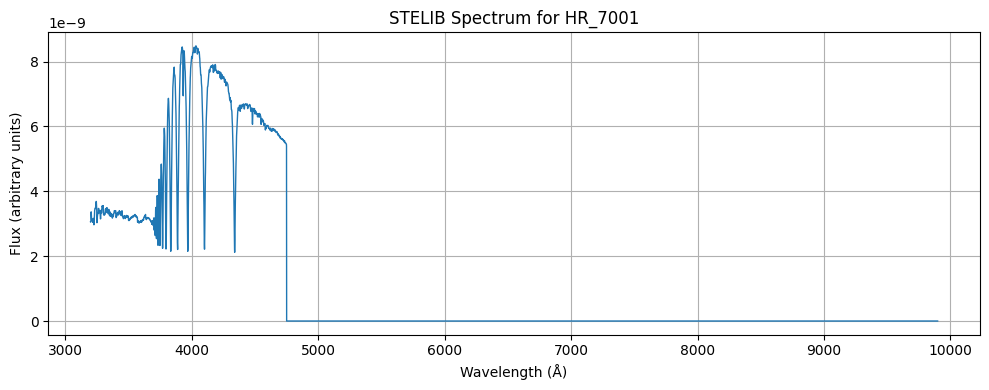

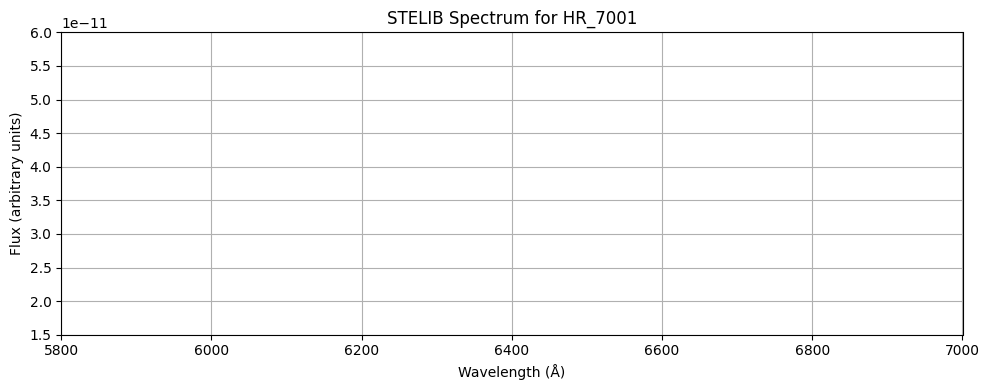

In [ ]:
cal_star = 'HR_7001'

spectrum_df = load_stelib_spectrum(cal_star, 'STELIB')
cal_waves,fluxes = spectrum_df['Wavelength'], spectrum_df['Flux']

print(spectrum_df.head())

plt.figure(figsize=(10, 4))
plt.plot(spectrum_df['Wavelength'], spectrum_df['Flux'], lw=1)
plt.xlabel('Wavelength (Å)')
plt.ylabel('Flux (arbitrary units)')
plt.title(f'STELIB Spectrum for {cal_star}')
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(spectrum_df['Wavelength'], spectrum_df['Flux'], lw=1)
plt.xlabel('Wavelength (Å)')
plt.ylabel('Flux (arbitrary units)')
plt.title(f'STELIB Spectrum for {cal_star}')
plt.xlim(5800,7000)
plt.ylim(0.15e-10,0.6e-10)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
from scipy.optimize import curve_fit, find_peaks

In [171]:
# Here are the functions to fit features

def gaussian(x, a, x0, sigma, offset):
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2)) + offset

def fit_feature(spec_cont, peak_center, width, height, width_guess=None):
    xmin, xmax = peak_center - width, peak_center + width
    peaks, _ = find_peaks(spec_cont[xmin:xmax], height=height, distance=10)
    if width_guess is None:
        width_guess = width
    x = np.arange(xmin, xmax)
    y = spec_cont[xmin:xmax]
    p0 = [height, peak_center, width_guess, 1]
    popt, pcov = curve_fit(gaussian, x, y, p0=p0)

    # Plot
    plt.figure(figsize=(15,5))
    plt.plot(x, y)
    plt.plot(x, gaussian(x, *popt))
    plt.title('Fit of absorption line')
    plt.xlabel('Pixel')
    plt.ylabel('Normalized intensity')
    plt.show()
    return popt

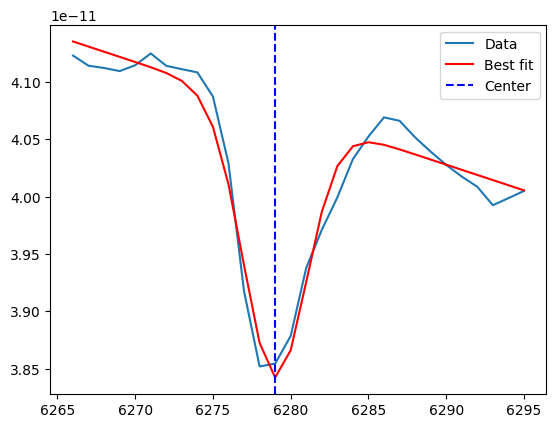

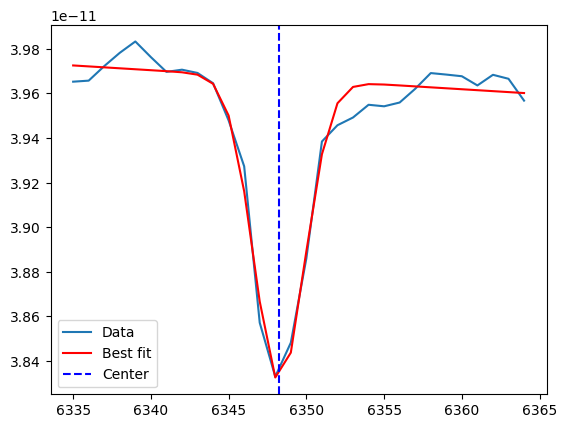

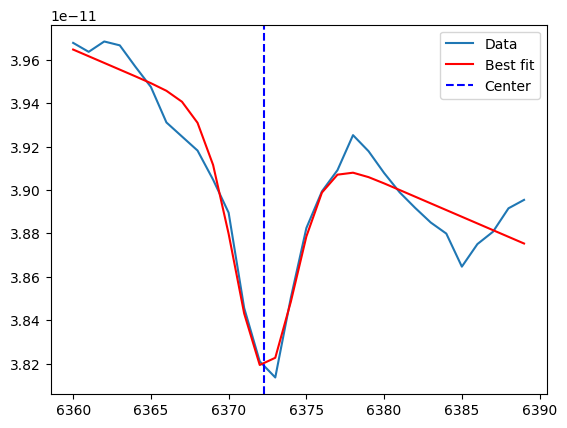

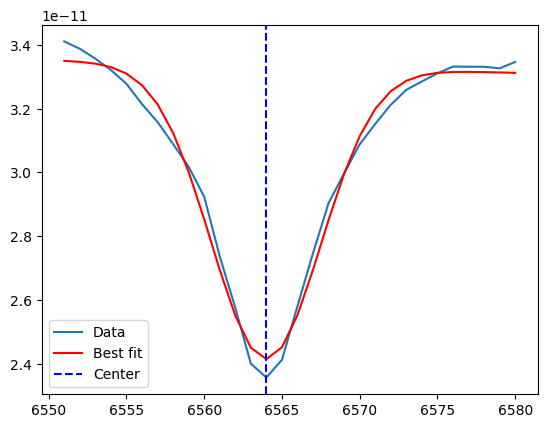

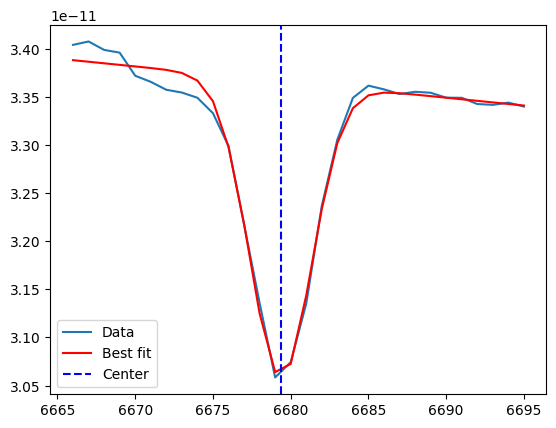

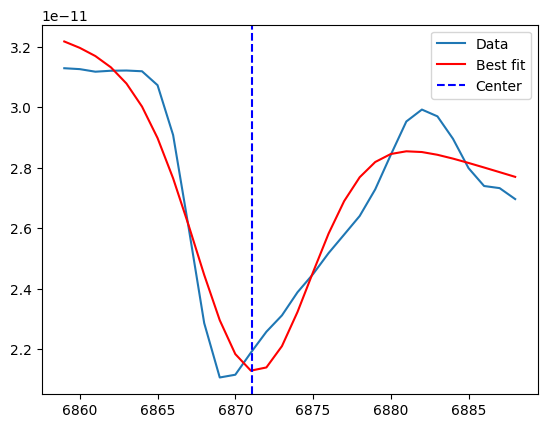

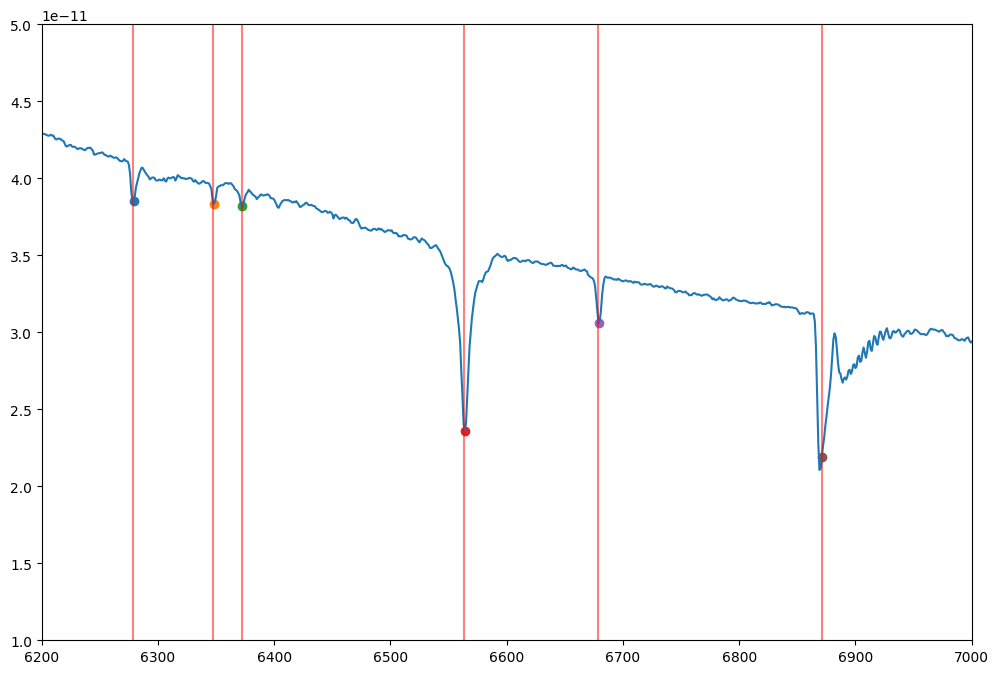

In [223]:
import numpy as np
from lmfit.models import GaussianModel, LinearModel

gauss = GaussianModel(prefix='g_')
linear = LinearModel(prefix='b_')
model = gauss + linear

wave_ref = spectrum_df['Wavelength'].to_numpy()
flux_ref = spectrum_df['Flux'].to_numpy()

fit_centers = []
fit_results = []

for w0 in corrected_wavelengths:
    # Select fitting window in WAVELENGTH space
    mask = (wave_ref > w0 - 15) & (wave_ref < w0 + 15)

    x = wave_ref[mask]
    y = flux_ref[mask]

    # Create parameters with good initial guesses
    params = model.make_params(
        g_amplitude=y.min() - y.max(),   # absorption line
        g_center=w0,
        g_sigma=2.0,
        b_slope=0.0,
        b_intercept=np.median(y)
    )

    # Optional but recommended bounds
    params['g_center'].set(min=w0 - 5, max=w0 + 5)
    params['g_sigma'].set(min=0.1, max=10)

    result = model.fit(y, params, x=x)

    plt.plot(x, y, label='Data')
    plt.plot(x, result.best_fit, 'r-', label='Best fit')
    plt.axvline(result.params['g_center'].value, color='b', linestyle='--', label='Center')
    plt.legend()
    plt.show()

    fit_centers.append(result.params['g_center'].value)
    fit_results.append(result)

plt.figure(figsize = (12,8))
plt.plot(wave_ref, flux_ref)
plt.xlim(6200,7000)
plt.ylim(0.1e-10, 0.5e-10)
for wavelength in corrected_wavelengths:
    plt.axvline(wavelength-2, color = 'red', alpha = 0.5)
for fit_center in fit_centers:
    plt.scatter(fit_center, flux_ref[np.argmin(np.abs(wave_ref-fit_center))])
plt.show()


=== Fit Report ===
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 9
    # data points      = 5
    # variables        = 3
    chi-square         = 0.22300957
    reduced chi-square = 0.11150478
    Akaike info crit   = -9.54989256
    Bayesian info crit = -10.7215788
[[Variables]]
    a:  2.1333e-05 +/- 2.1497e-06 (10.08%) (init = 1e-06)
    b:  0.38035105 +/- 0.00715106 (1.88%) (init = 0)
    c:  5788.27151 +/- 5.72461208 (0.10%) (init = 6372.276)
[[Correlations]] (unreported correlations are < 0.100)
    C(a, b) = -0.9980
    C(b, c) = -0.9977
    C(a, c) = +0.9918

R^2 = 0.999998

Pixel location of H-alpha = 1845.355
New solution λ at Hα pixel  = 6562.8000 Å
Old solution λ at Hα pixel  = 6561.2742 Å
Difference (new - old)       = 1.5258 Å
Uncertainty at Hα pixel     = ±0.2557 Å


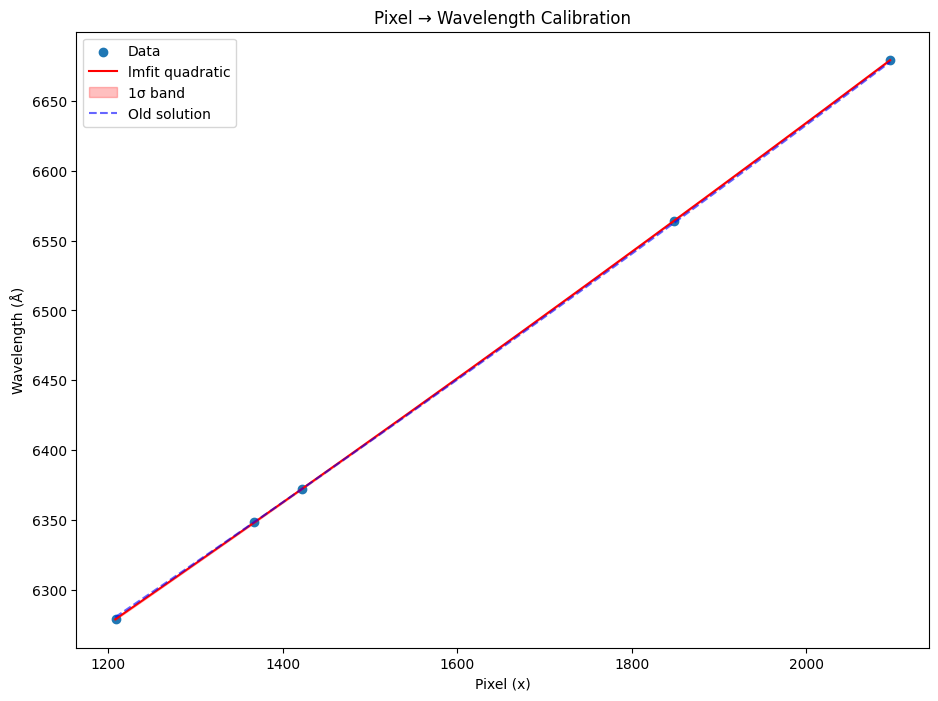

In [225]:
from lmfit import Minimizer, Parameters, report_fit

# ---------------------------------------------------------
# Data
# ---------------------------------------------------------
xdata = np.asarray(extract_peak_centers)
ydata = np.asarray(fit_centers)

# Pixel grid for visualization
low = int(np.min(xdata))
high = int(np.max(xdata))
xplot = np.linspace(low, high, high-low+1)

# ---------------------------------------------------------
# lmfit model
# ---------------------------------------------------------
def residual(params, x, data):
    a = params['a'].value
    b = params['b'].value
    c = params['c'].value
    return a*x**2 + b*x + c - data

params = Parameters()
params.add('a', value=1e-6)
params.add('b', value=0.0)
params.add('c', value=np.median(ydata))

mini = Minimizer(residual, params, fcn_args=(xdata, ydata))
result = mini.minimize()

print("\n=== Fit Report ===")
report_fit(result)

a = result.params['a'].value
b = result.params['b'].value
c = result.params['c'].value

# Best-fit curve
yfit = a*xplot**2 + b*xplot + c

# ---------------------------------------------------------
# R^2 calculation
# ---------------------------------------------------------
resid = ydata - (a*xdata**2 + b*xdata + c)
ss_res = np.sum(resid**2)
ss_tot = np.sum((ydata - np.mean(ydata))**2)
r2 = 1 - ss_res/ss_tot
print(f"\nR^2 = {r2:.6f}")

# ---------------------------------------------------------
# Parameter covariance → uncertainty propagation
# ---------------------------------------------------------
cov = result.covar
if cov is None:
    print("WARNING: covariance matrix unavailable — uncertainties cannot be computed.")
else:
    # Build Jacobian for every pixel in xplot
    J = np.vstack([xplot**2, xplot, np.ones_like(xplot)])  # (3,N)
    var_y = np.einsum('ij,jk,ik->i', J.T, cov, J.T)
    sigma_y = np.sqrt(np.maximum(var_y,0))

# ---------------------------------------------------------
# OLD wavelength solution
# ---------------------------------------------------------
def old_solution(x):
    return 5809.515939 + 0.3564304348*x + 0.00002760895652*x**2

# ---------------------------------------------------------
# FIND PIXEL COORDINATE OF H-alpha
# new solution solves a*x^2 + b*x + (c - 6562.8) = 0
# ---------------------------------------------------------
Hα = 6562.8
coeffs = [a, b, c - Hα]
roots = np.roots(coeffs)

# pick the real root inside pixel range
x_Ha = roots[np.isreal(roots)].real
x_Ha = x_Ha[(x_Ha>=low) & (x_Ha<=high)]
if len(x_Ha) == 0:
    print("Could not determine x-pixel for H-alpha inside fit range.")
    x_Ha = None
else:
    x_Ha = float(x_Ha[0])
    print(f"\nPixel location of H-alpha = {x_Ha:.3f}")

    # wavelength from both solutions
    new_λ_Ha = a*x_Ha**2 + b*x_Ha + c
    old_λ_Ha = old_solution(x_Ha)
    diff_Ha = new_λ_Ha - old_λ_Ha

    print(f"New solution λ at Hα pixel  = {new_λ_Ha:.4f} Å")
    print(f"Old solution λ at Hα pixel  = {old_λ_Ha:.4f} Å")
    print(f"Difference (new - old)       = {diff_Ha:.4f} Å")

    # uncertainty at that pixel
    if cov is not None:
        J_Ha = np.array([x_Ha**2, x_Ha, 1.0])
        var_Ha = J_Ha.T @ cov @ J_Ha
        sigma_Ha = np.sqrt(np.maximum(var_Ha, 0))
        print(f"Uncertainty at Hα pixel     = ±{sigma_Ha:.4f} Å")

# ---------------------------------------------------------
# Plotting
# ---------------------------------------------------------
plt.figure(figsize=(11,8))
plt.scatter(xdata, ydata, label='Data')
plt.plot(xplot, yfit, 'r', label='lmfit quadratic')

if cov is not None:
    plt.fill_between(xplot, yfit - sigma_y, yfit + sigma_y,
                     alpha=0.25, color='red', label='1σ band')

plt.plot(xplot, old_solution(xplot), 'b--', alpha=0.6, label='Old solution')
plt.xlabel('Pixel (x)')
plt.ylabel('Wavelength (Å)')
plt.title('Pixel → Wavelength Calibration')
plt.legend()
plt.show()

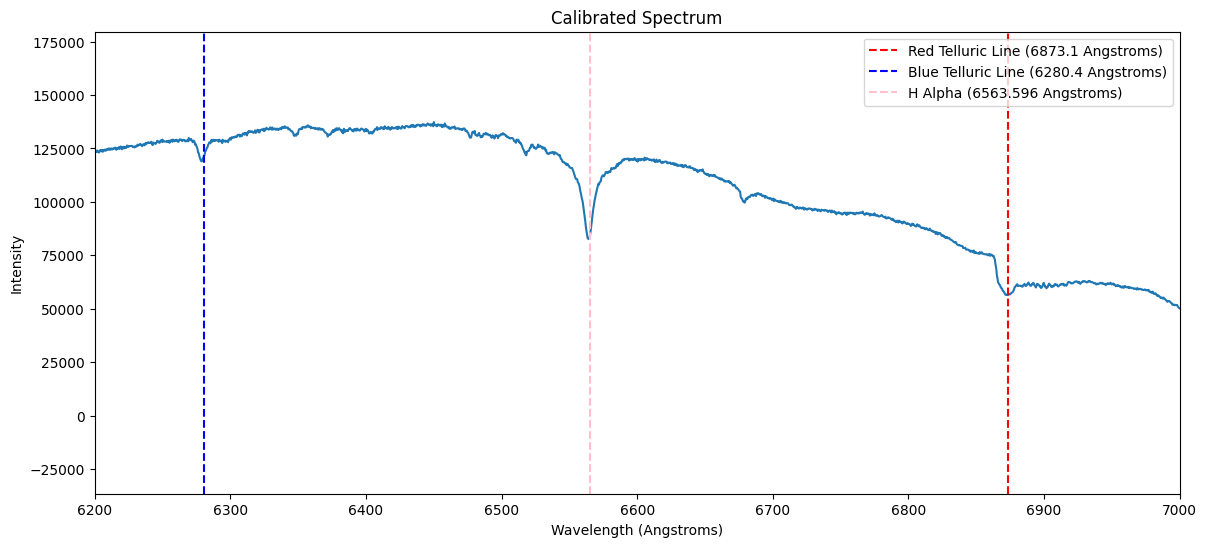

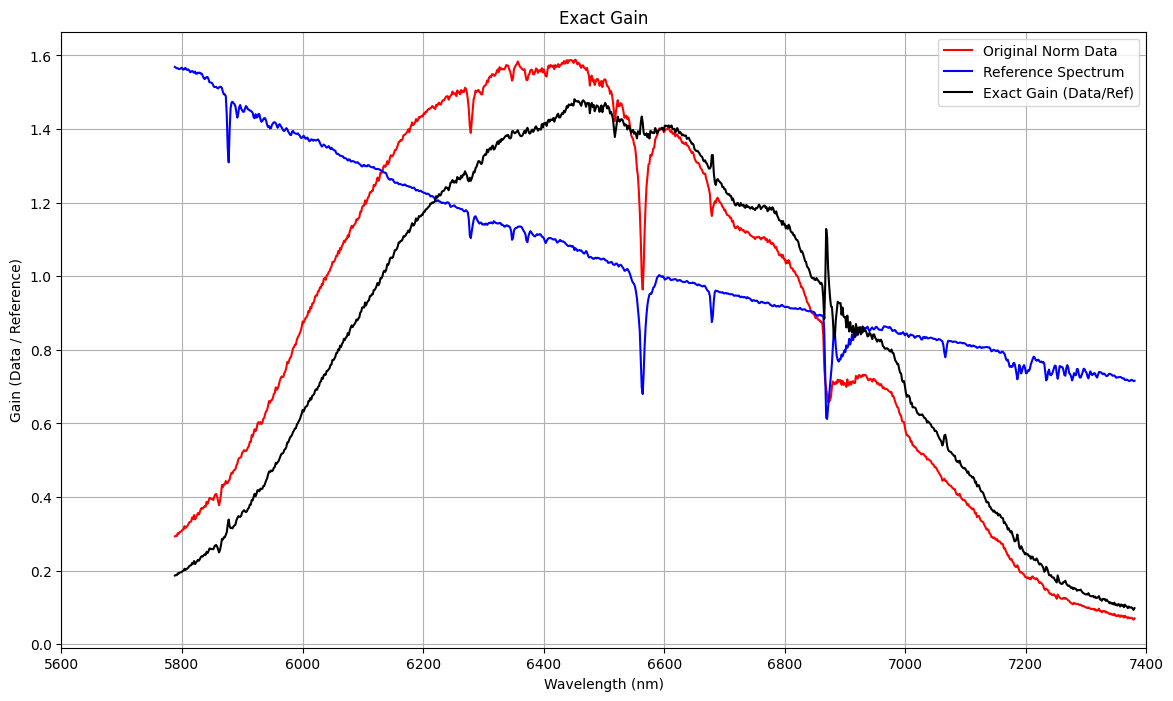

In [ ]:
# Create an initial calibrated spectrum using 2500 pixels left of the telluric line as a starting point

calibrated_spectrum, spectrum_out = new_wavelength_calibrate(spectrum[2][50:], a, b, c)
# calibrated_spectrum, spectrum_out = wavelength_calibrate(spectrum[2][45:])
# calibrated_spectrum, spectrum_out = new_wavelength_calibrate(col_sum[telluric_x - 2500:], a, b, c)

wave_grid, flux_data_interp, flux_ref_interp = match_and_interpolate(calibrated_spectrum, spectrum_out/np.median(spectrum_out), cal_waves, fluxes/np.median(fluxes))

# plt.figure(1,figsize=(12,7))
# plt.plot(wave_grid, flux_data_interp, color = 'red')
# plt.plot(wave_grid, flux_ref_interp, color = 'blue')
# plt.xlim(5600, 7400)
# # plt.ylim(0,2e15)
# plt.xlabel('Wavelength (nm)')
# plt.ylabel('Gain (Data / Reference)')
# plt.title('Exact Gain')
# plt.grid(True)
# plt.show()

# Now you can calculate gain:
gain = flux_data_interp / flux_ref_interp

plt.figure(1,figsize=(14,8))
plt.plot(wave_grid, flux_data_interp, color = 'red', label = 'Original Norm Data')
plt.plot(wave_grid, flux_ref_interp, color = 'blue', label = 'Reference Spectrum')
plt.plot(wave_grid, gain, color = 'black', label = 'Exact Gain (Data/Ref)')
plt.xlim(5600, 7400)
# plt.ylim(0,2e15)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Gain (Data / Reference)')
plt.title('Exact Gain')
plt.legend()
plt.grid(True)
plt.show()

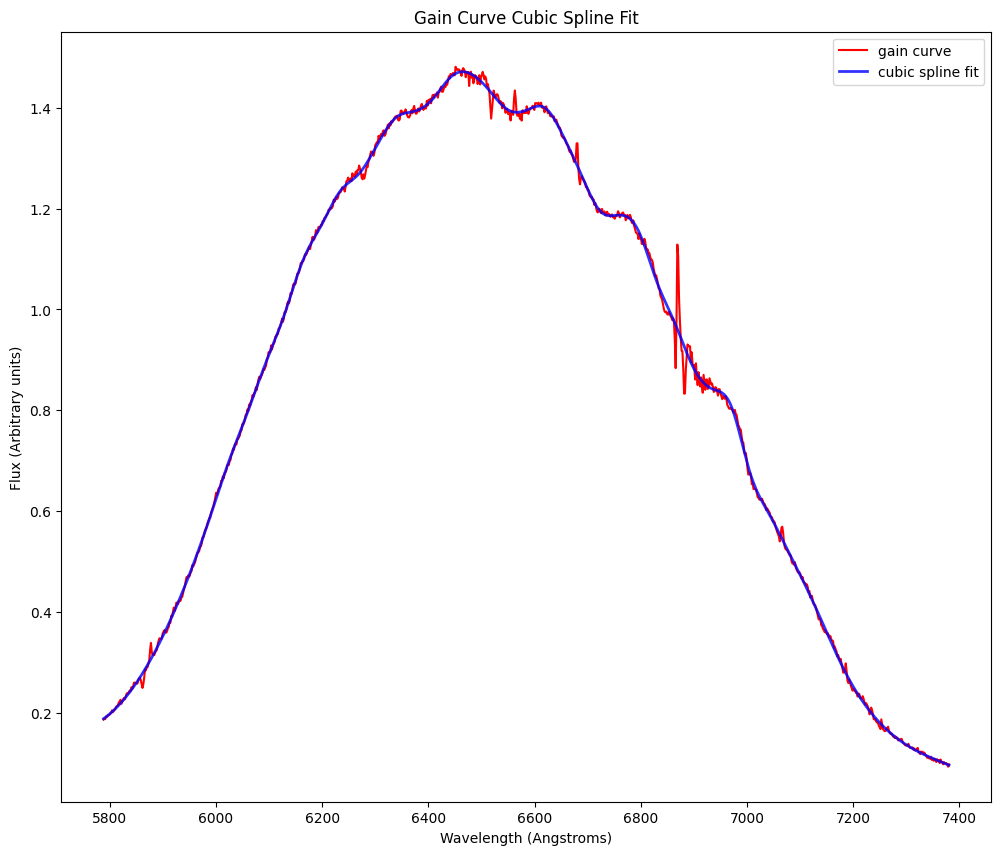

In [ ]:
import numpy as np
from scipy.interpolate import LSQUnivariateSpline

# ~400 Å spacing (good for gain curves)
# knots = np.linspace(wave_grid.min()+200, wave_grid.max()-200, 35)

spline = LSQUnivariateSpline(wave_grid, gain, t=knots, k=3)
gain_smooth = spline(wave_grid)

plt.figure(figsize = (12,10))
plt.plot(wave_grid, gain, color = 'red', label = 'gain curve')
plt.plot(wave_grid, gain_smooth, color = 'blue', alpha = 0.8, linewidth = 2, label = 'cubic spline fit')
plt.xlabel('Wavelength (Angstroms)')
plt.ylabel('Flux (Arbitrary units)')
plt.title('Gain Curve Cubic Spline Fit')
plt.legend()
plt.show()

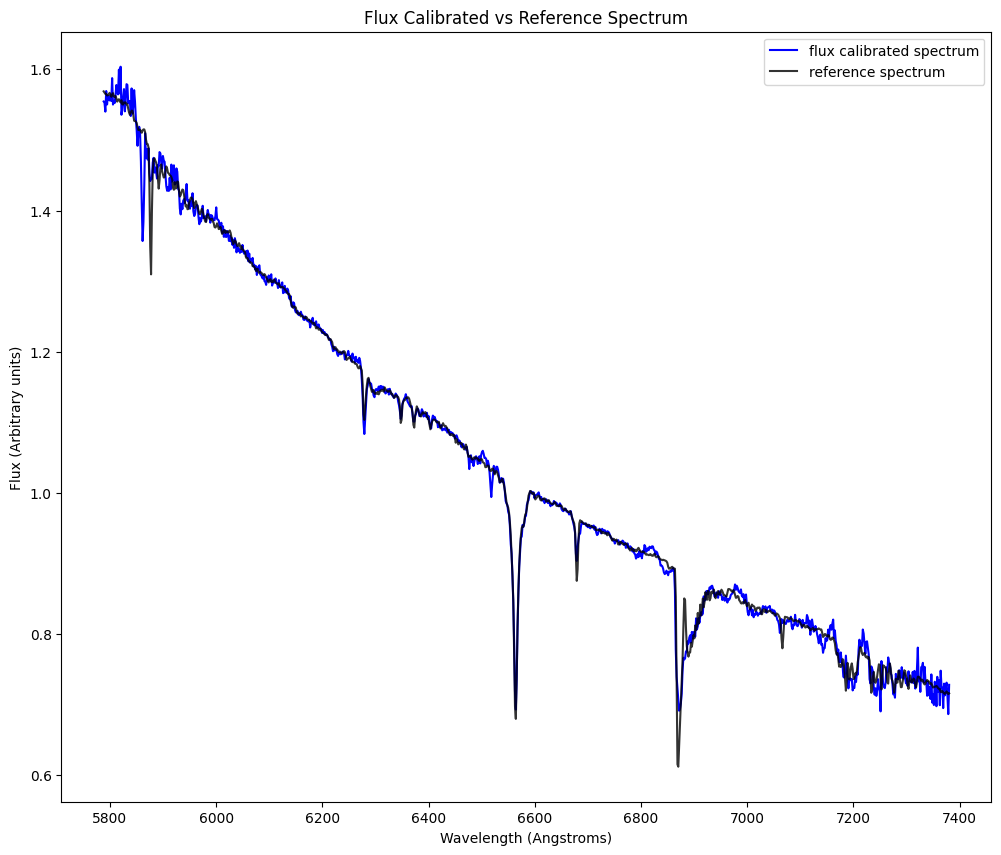

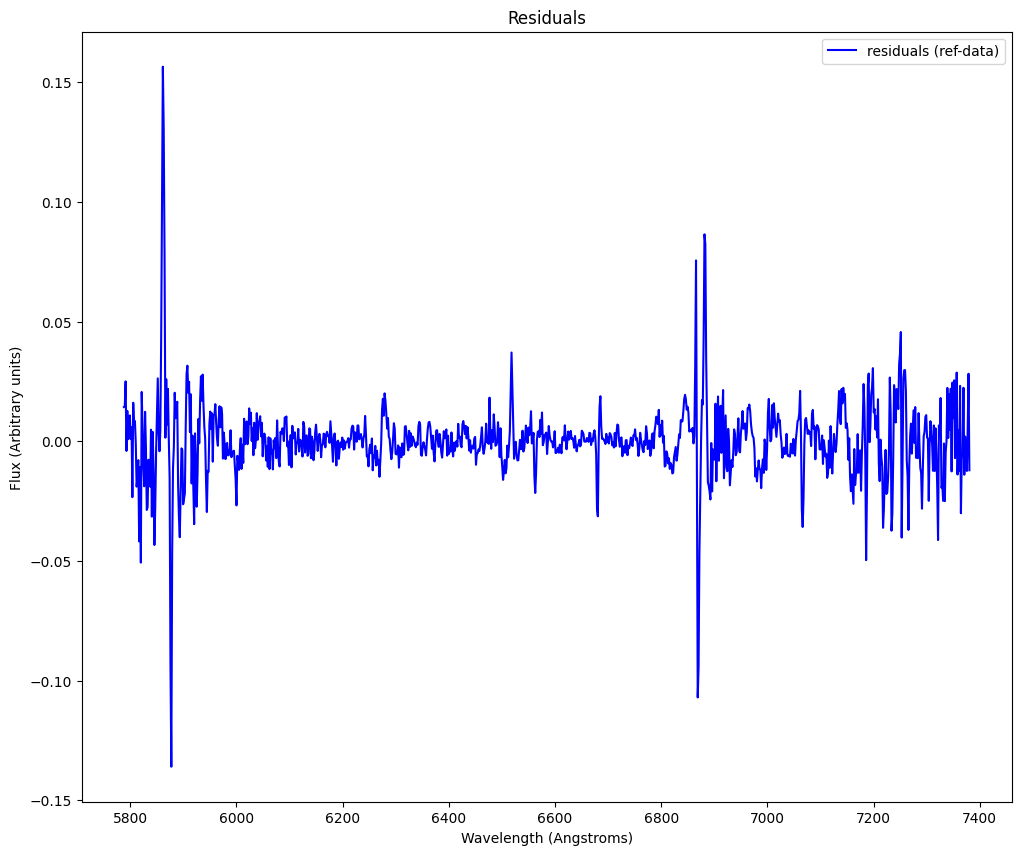

In [228]:
cal_spec = flux_data_interp/gain_smooth

plt.figure(figsize = (12,10))
# plt.plot(wave_grid, flux_data_interp, color = 'red', label = 'original norm data')
# plt.plot(wave_grid, gain_smooth, color = 'green', label = 'gain curve')
plt.plot(wave_grid, cal_spec, color = 'blue', label = 'flux calibrated spectrum')
plt.plot(wave_grid, flux_ref_interp, color = 'black', alpha = 0.8, label = 'reference spectrum')
plt.xlabel('Wavelength (Angstroms)')
plt.ylabel('Flux (Arbitrary units)')
plt.title('Flux Calibrated vs Reference Spectrum')
plt.legend()
plt.show()

plt.figure(figsize = (12,10))
# plt.plot(wave_grid, flux_data_interp, color = 'red', label = 'original norm data')
# plt.plot(wave_grid, gain_smooth, color = 'green', label = 'gain curve')
plt.plot(wave_grid, flux_ref_interp - cal_spec, color = 'blue', label = 'residuals (ref-data)')
plt.xlabel('Wavelength (Angstroms)')
plt.ylabel('Flux (Arbitrary units)')
plt.title('Residuals')
plt.legend()
plt.show()

# Export to csv

In [206]:
# HRG Wavelength Solution

import pandas as pd
from pathlib import Path

calib_dir = Path.cwd() / "grism_calib"
calib_dir.mkdir(exist_ok=True)

df_wl = pd.DataFrame([{
    "grism": "highres",
    "a": a,
    "b": b,
    "c": c,
    "units": "angstrom"
}])

wl_path = calib_dir / "wavelength_solutions.csv"

# append-safe for future lowres
if wl_path.exists():
    df_wl.to_csv(wl_path, mode="w", header = True, index=False)
else:
    df_wl.to_csv(wl_path, header = True, index=False)

In [207]:
# HRG Gain Spline

import pandas as pd
from pathlib import Path

calib_dir = Path.cwd() / "grism_calib"
calib_dir.mkdir(exist_ok=True)

df_gain = pd.DataFrame({
    "grism": "highres",
    "wavelength": wave_grid,
    "gain": gain_smooth
})

gain_path = calib_dir / "gain_curves.csv"

# overwrite intentionally
df_gain.to_csv(gain_path, index=False)

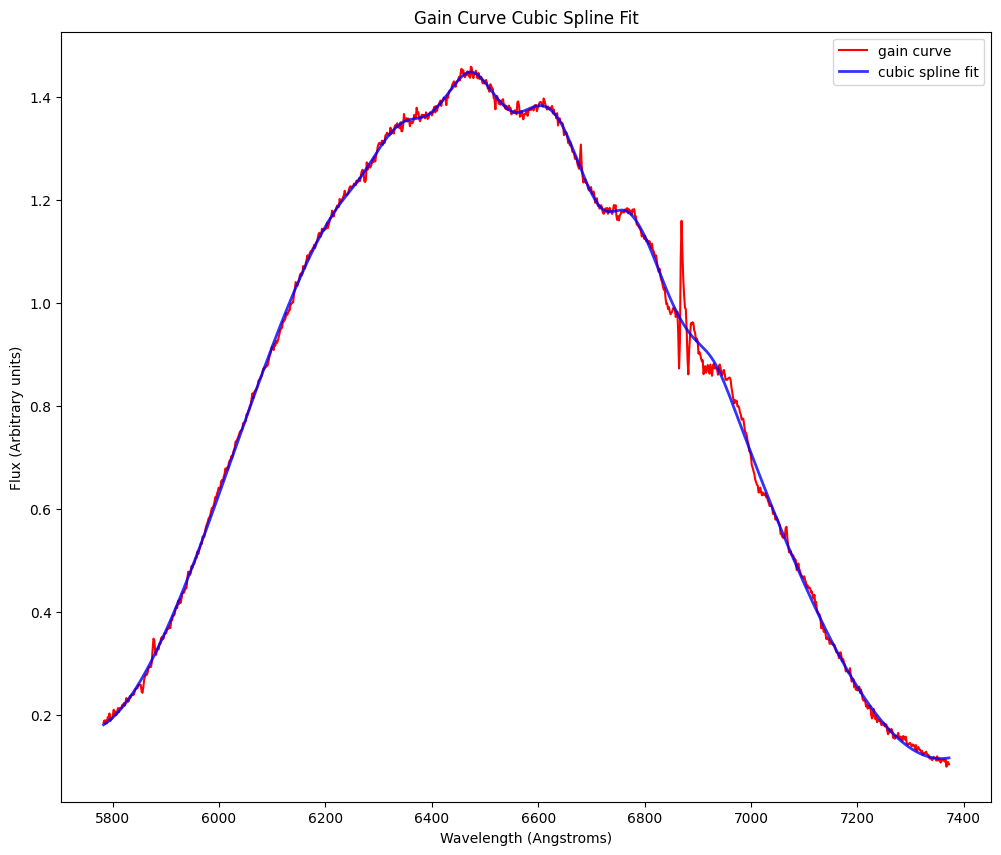

In [208]:
# Sanity check reconstruction

import pandas as pd
from scipy.interpolate import CubicSpline

df = pd.read_csv("grism_calib/gain_curves.csv")

g = df[df["grism"] == "highres"].sort_values("wavelength")

gain_spline = CubicSpline(
    g["wavelength"].values,
    g["gain"].values,
    bc_type="natural"
)

gain_corrected = gain_spline(wave_grid)

plt.figure(figsize = (12,10))
plt.plot(wave_grid, gain, color = 'red', label = 'gain curve')
# plt.plot(g["wavelength"].values, g["gain"].values, color = 'blue', alpha = 0.8, linewidth = 2, label = 'cubic spline fit')
plt.plot(wave_grid, gain_corrected, color = 'blue', alpha = 0.8, linewidth = 2, label = 'cubic spline fit')
plt.xlabel('Wavelength (Angstroms)')
plt.ylabel('Flux (Arbitrary units)')
plt.title('Gain Curve Cubic Spline Fit')
# plt.xlim(6200,7000)
# plt.ylim(0,2)
plt.legend()
plt.show()
